# **Financial Markets Analytics PROJECT**



In [51]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import statsmodels

In [52]:
path = "./SPX500Original.xlsm"  

prices = pd.read_excel(path, sheet_name="Price", header=[0, 1], index_col=0, engine="openpyxl")
#set dataset index with col = 0, date YYYY-MM-DD
prices.index = pd.to_datetime(prices.index)

print(prices.shape)
prices.head()

(336, 1355)


,MMM UN Equity,ABT UN Equity,2056Q UN Equity,AMD UN Equity,45200Q UN Equity,968734Q UN Equity,950967Q UN Equity,APD UN Equity,1281683D UN Equity,1312089D UN Equity,...,CBOE UF Equity,UAL UW Equity,WCG UN Equity,AMD UW Equity,FTNT UW Equity,LIN UN Equity,ROL UN Equity,JKHY UW Equity,KEYS UN Equity,REG UW Equity
data,3M Co,Abbott Laboratories,ACME-Cleveland Corp,Advanced Micro Devices Inc,AEP Texas Inc,Aeroquip-Vickers Inc,AIG Life Holdings Inc,Air Products & Chemicals Inc,Alberto-Culver Co,Albertson's LLC,...,Cboe Global Markets Inc,United Continental Holdings Inc,WellCare Health Plans Inc,Advanced Micro Devices Inc,Fortinet Inc,Linde PLC,Rollins Inc,Jack Henry & Associates Inc,Keysight Technologies Inc,Regency Centers Corp
1990-12-31,20.629,5.0348,4.750,2.4375,22.0000,18.250,7.6875,12.6542,9.5408,18.2500,...,NaN,NaN,NaN,NaN,NaN,NaN,1.2437,0.1250,NaN,NaN
1991-01-31,20.419,4.8810,5.375,3.5625,22.0000,22.000,8.1875,13.6364,9.2897,19.3750,...,NaN,NaN,NaN,NaN,NaN,NaN,1.2144,0.1667,NaN,NaN
1991-02-28,21.291,5.1887,6.625,4.0625,22.0000,24.375,9.1875,14.8499,8.8234,19.2500,...,NaN,NaN,NaN,NaN,NaN,NaN,1.3242,0.2292,NaN,NaN
1991-03-29,21.291,5.3705,6.625,5.1875,22.5625,22.500,9.6250,15.6588,8.5723,23.4375,...,NaN,NaN,NaN,NaN,NaN,NaN,1.4047,0.2500,NaN,NaN
1991-04-30,21.441,5.6642,6.500,6.1250,23.3750,22.125,9.6875,14.4165,7.2452,23.9375,...,NaN,NaN,NaN,NaN,NaN,NaN,1.4120,0.2986,NaN,NaN


----------
## **BLOCK 1 - DATA LOADING AND CLEANING**

In [53]:
tickers = prices.columns.get_level_values(0)
names = prices.columns.get_level_values(1) 

ticker_to_name = dict(zip(tickers, names))
prices.columns = tickers

print(prices.shape)
prices.head()

(336, 1355)


,MMM UN Equity,ABT UN Equity,2056Q UN Equity,AMD UN Equity,45200Q UN Equity,968734Q UN Equity,950967Q UN Equity,APD UN Equity,1281683D UN Equity,1312089D UN Equity,...,CBOE UF Equity,UAL UW Equity,WCG UN Equity,AMD UW Equity,FTNT UW Equity,LIN UN Equity,ROL UN Equity,JKHY UW Equity,KEYS UN Equity,REG UW Equity
1990-12-31,20.629,5.0348,4.750,2.4375,22.0000,18.250,7.6875,12.6542,9.5408,18.2500,...,NaN,NaN,NaN,NaN,NaN,NaN,1.2437,0.1250,NaN,NaN
1991-01-31,20.419,4.8810,5.375,3.5625,22.0000,22.000,8.1875,13.6364,9.2897,19.3750,...,NaN,NaN,NaN,NaN,NaN,NaN,1.2144,0.1667,NaN,NaN
1991-02-28,21.291,5.1887,6.625,4.0625,22.0000,24.375,9.1875,14.8499,8.8234,19.2500,...,NaN,NaN,NaN,NaN,NaN,NaN,1.3242,0.2292,NaN,NaN
1991-03-29,21.291,5.3705,6.625,5.1875,22.5625,22.500,9.6250,15.6588,8.5723,23.4375,...,NaN,NaN,NaN,NaN,NaN,NaN,1.4047,0.2500,NaN,NaN
1991-04-30,21.441,5.6642,6.500,6.1250,23.3750,22.125,9.6875,14.4165,7.2452,23.9375,...,NaN,NaN,NaN,NaN,NaN,NaN,1.4120,0.2986,NaN,NaN


### Data availability across stocks

Before selecting candidate stocks for the pairs trading universe, we need to understand 
how complete the price history is for each of the 1,355 stocks in the dataset. Since 
S&P500 constituents change over time (delistings, M&A, new listings), many stocks only 
have partial price histories.

The histogram below shows, for each stock, how many months (out of 336 total) have a 
non-missing price observation.

In [54]:
availability = prices.notna().sum(axis=0) 
display(availability.head())
print(availability.describe())

MMM UN Equity       336
ABT UN Equity       336
2056Q UN Equity     336
AMD UN Equity       336
45200Q UN Equity    336
dtype: int64

count    1355.000000
mean      287.297417
std        79.423714
min         1.000000
25%       264.000000
50%       336.000000
75%       336.000000
max       336.000000
dtype: float64


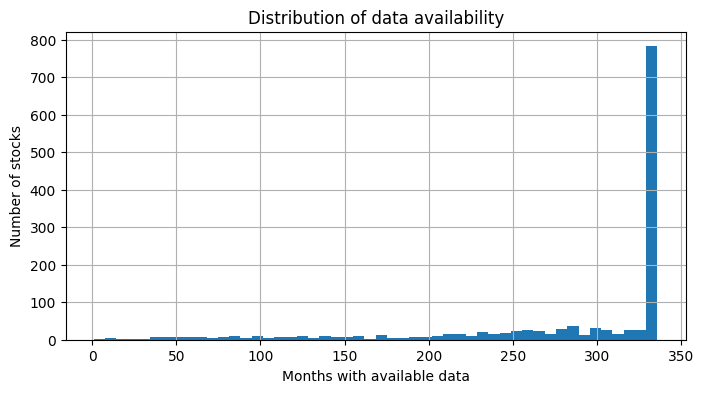

In [55]:
availability.hist(bins=50, figsize=(8,4))
plt.xlabel("Months with available data")
plt.ylabel("Number of stocks")
plt.title("Distribution of data availability")
plt.show()

The distribution is strongly bimodal. A large block of roughly 780 stocks has 
near-complete histories (close to 336 months), corresponding to constituents that 
remained in the index for most or all of the sample period. The remaining stocks are 
spread thinly across the full range, reflecting stocks that entered or exited the index 
at some point during the 28-year sample.

This pattern motivates a minimum-history threshold: stocks with very short histories 
cannot support a meaningful formation period (12 months) plus trading period (6 months) 
plus enough rolling windows to validate the strategy over time, and will therefore be 
excluded from the candidate universe.

In [56]:
for threshold in [60, 120, 180, 240, 300]:
    n_stocks = (availability >= threshold).sum()
    print(f"Threshold {threshold} months: {n_stocks} stocks remain")

Threshold 60 months: 1322 stocks remain
Threshold 120 months: 1260 stocks remain
Threshold 180 months: 1188 stocks remain
Threshold 240 months: 1091 stocks remain
Threshold 300 months: 887 stocks remain


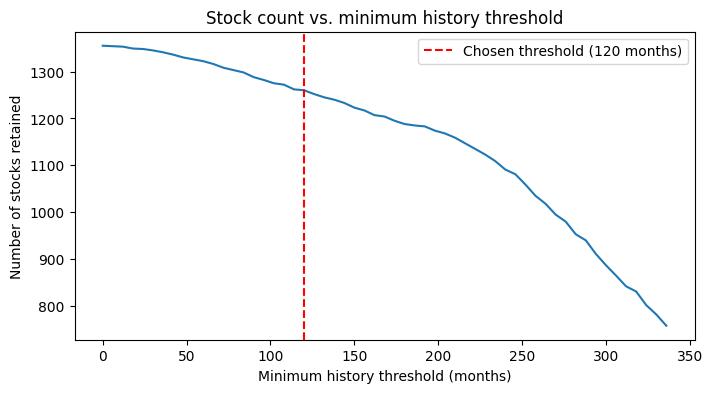

In [57]:
thresholds = range(0, 337, 6)
n_remaining = [(availability >= t).sum() for t in thresholds]

plt.figure(figsize=(8,4))
plt.plot(thresholds, n_remaining)
plt.axvline(120, color='red', linestyle='--', label='Chosen threshold (120 months)')
plt.xlabel("Minimum history threshold (months)")
plt.ylabel("Number of stocks retained")
plt.title("Stock count vs. minimum history threshold")
plt.legend()
plt.show()

### Choice of minimum history threshold

The drop-off in stock count is gradual across thresholds (1,322 stocks survive at 60 
months, down to 887 at 300 months), so there is no natural "elbow" in the data that 
imposes a single correct choice — this is a judgment call that trades off universe size 
against history depth.

We set the minimum history threshold at **120 months (10 years)**. This retains 1,260 
of the 1,355 stocks (93% of the universe), keeping the candidate pool large enough for 
a statistically meaningful pair-selection step, while guaranteeing enough history to 
support multiple independent formation (12-month) + trading (6-month) cycles in the 
backtest, rather than relying on a single period. A stricter threshold (e.g. 300 months) 
would further reduce noise from short-lived constituents but would also concentrate the 
universe on long-term survivors, amplifying survivorship bias beyond what is already 
present in the dataset. 

The survival curve confirms there is no elbow point in the data: the number of retained 
stocks decreases smoothly and monotonically as the threshold increases, with no abrupt 
discontinuity that would suggest a "natural" cutoff. This supports treating the choice 
of 120 months as a deliberate trade-off rather than a data-driven necessity.

In [58]:
min_history = 120
selected_tickers = availability[availability >= min_history].index
prices_filtered = prices[selected_tickers]

print(f"Stocks retained: {prices_filtered.shape[1]} out of {prices.shape[1]}")
prices_filtered.head()

Stocks retained: 1260 out of 1355


,MMM UN Equity,ABT UN Equity,2056Q UN Equity,AMD UN Equity,45200Q UN Equity,968734Q UN Equity,950967Q UN Equity,APD UN Equity,1281683D UN Equity,1312089D UN Equity,...,BR UN Equity,EVRG UN Equity,HFC UN Equity,CPRT UW Equity,ANDV US Equity,UAL UW Equity,WCG UN Equity,LIN UN Equity,ROL UN Equity,JKHY UW Equity
1990-12-31,20.629,5.0348,4.750,2.4375,22.0000,18.250,7.6875,12.6542,9.5408,18.2500,...,NaN,NaN,NaN,NaN,3.3125,NaN,NaN,NaN,1.2437,0.1250
1991-01-31,20.419,4.8810,5.375,3.5625,22.0000,22.000,8.1875,13.6364,9.2897,19.3750,...,NaN,NaN,NaN,NaN,3.3750,NaN,NaN,NaN,1.2144,0.1667
1991-02-28,21.291,5.1887,6.625,4.0625,22.0000,24.375,9.1875,14.8499,8.8234,19.2500,...,NaN,NaN,NaN,NaN,3.8125,NaN,NaN,NaN,1.3242,0.2292
1991-03-29,21.291,5.3705,6.625,5.1875,22.5625,22.500,9.6250,15.6588,8.5723,23.4375,...,NaN,NaN,NaN,NaN,4.1250,NaN,NaN,NaN,1.4047,0.2500
1991-04-30,21.441,5.6642,6.500,6.1250,23.3750,22.125,9.6875,14.4165,7.2452,23.9375,...,NaN,NaN,NaN,NaN,4.3125,NaN,NaN,NaN,1.4120,0.2986


### Internal gaps check

Before proceeding, we verify whether any selected stock has missing values *within* 
its active trading period (as opposed to missing values before listing or after 
delisting, which are expected and not a data quality issue).

In [59]:
internal_gaps_count = 0

for ticker in prices_filtered.columns:
    series = prices_filtered[ticker]
    
    valid_indices = series[series.notna()].index
    first_date = valid_indices[0]
    last_date = valid_indices[-1]
    
    middle_part = series.loc[first_date:last_date]
    
    if middle_part.isna().sum() > 0:
        internal_gaps_count += 1

print(f"Stocks with internal gaps: {internal_gaps_count} out of {prices_filtered.shape[1]}")

Stocks with internal gaps: 0 out of 1260


None of the 1,260 retained stocks have internal gaps. All missing values are 
located at the edges of each stock's time series, consistent with entry/exit from the 
index. This means no interpolation or imputation is needed at this stage — the dataset 
is already clean in this respect.

### Log-price transformation

The assignment defines the cointegration regression generically as $y_t = \alpha + \beta x_t + \varepsilon_t$,
without specifying whether $y_t, x_t$ should be raw prices or log-prices. This is one of
the subjective choices we need to make and justify ourselves.

Note that Gatev et al. (2006) — the reference paper for this project — use a different
methodology (the distance method): they normalize cumulative total return indices to a
common starting value and match pairs by minimizing the Euclidean distance between these
normalized series. This is a separate transformation from the log-price approach, serving
a different purpose: comparability of scale for distance-based matching, rather than
variance stabilization.

Since we adopt the cointegration-based approach (Engle-Granger), our use of log-prices
follows standard econometric practice for cointegration analysis rather than Gatev's
methodology. Working in logarithms is preferred here for two reasons:

1. **Variance stabilization.** Raw stock prices typically exhibit increasing variance over
   time as the price level grows (multiplicative dynamics). Taking logs converts this
   multiplicative behavior into additive behavior, which is closer to the assumptions
   underlying the OLS regression used to estimate the hedge ratio $\beta$ and the ADF
   test applied to the residuals.

2. **Scale invariance of the spread.** The spread $S_t = \ln(P^A_t) - \beta \ln(P^B_t)$
   is interpretable as a relative (percentage-based) deviation between the two stocks,
   independent of their absolute price levels. A spread built on raw prices, by contrast,
   would scale with the price level of each stock and would not be directly comparable
   across different pairs.

We therefore work with log-prices for the cointegration regression and the spread
construction, while log-returns (computed separately) will be used later for risk and
performance metrics (volatility, Sharpe ratio).

In [60]:
log_prices = np.log(prices_filtered) #log-price

log_returns = log_prices.diff() #monthly log-return 

print(log_prices.shape)
print(log_returns.shape)
#display(prices_filtered)
log_returns.head()

(336, 1260)
(336, 1260)


,MMM UN Equity,ABT UN Equity,2056Q UN Equity,AMD UN Equity,45200Q UN Equity,968734Q UN Equity,950967Q UN Equity,APD UN Equity,1281683D UN Equity,1312089D UN Equity,...,BR UN Equity,EVRG UN Equity,HFC UN Equity,CPRT UW Equity,ANDV US Equity,UAL UW Equity,WCG UN Equity,LIN UN Equity,ROL UN Equity,JKHY UW Equity
1990-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-31,-0.010232,-0.031024,0.123614,0.379490,0.000000,0.186877,0.063013,0.074754,-0.026671,0.059818,...,NaN,NaN,NaN,NaN,0.018692,NaN,NaN,NaN,-0.023841,0.287882
1991-02-28,0.041819,0.061133,0.209092,0.131336,0.000000,0.102516,0.115235,0.085250,-0.051499,-0.006473,...,NaN,NaN,NaN,NaN,0.121890,NaN,NaN,NaN,0.086558,0.318399
1991-03-29,0.000000,0.034438,0.000000,0.244453,0.025247,-0.080043,0.046520,0.053040,-0.028871,0.196826,...,NaN,NaN,NaN,NaN,0.078781,NaN,NaN,NaN,0.059015,0.086866
1991-04-30,0.007021,0.053245,-0.019048,0.166127,0.035378,-0.016807,0.006473,-0.082660,-0.168197,0.021109,...,NaN,NaN,NaN,NaN,0.044452,NaN,NaN,NaN,0.005183,0.177644


In [61]:
print(log_returns.notna().sum().sum())   # totale osservazioni valide di log-return
print(log_prices.notna().sum().sum())    # totale osservazioni valide di log-price

print(abs(log_returns.notna().sum().sum() - log_prices.notna().sum().sum()))

print(log_returns.isna().sum(axis=0).describe())  # NaN per titolo, nei log-returns

381455
382715
1260
count    1260.000000
mean       33.257937
std        53.470763
min         1.000000
25%         1.000000
50%         1.000000
75%        51.000000
max       217.000000
dtype: float64


### Log-returns consistency check

As expected, the number of valid log-return observations (381,455) is exactly 1,260 
fewer than the number of valid log-price observations (382,715) — one fewer observation 
per stock, corresponding to the first available month of each series, for which no 
prior price exists to compute a return. The distribution of missing values per stock in 
the log-returns confirms this: more than half of the stocks have exactly one missing 
value (the structural one), consistent with the earlier finding that there are no 
internal gaps in the dataset.

### Visual inspection of log-prices

Before moving to pair selection, we visually inspect the log-price series of a few 
sample stocks to catch any obvious anomaly (sudden jumps, implausible values) that the 
numerical checks performed so far might not have revealed. This also gives a first 
intuitive look at the data before introducing any statistical machinery.

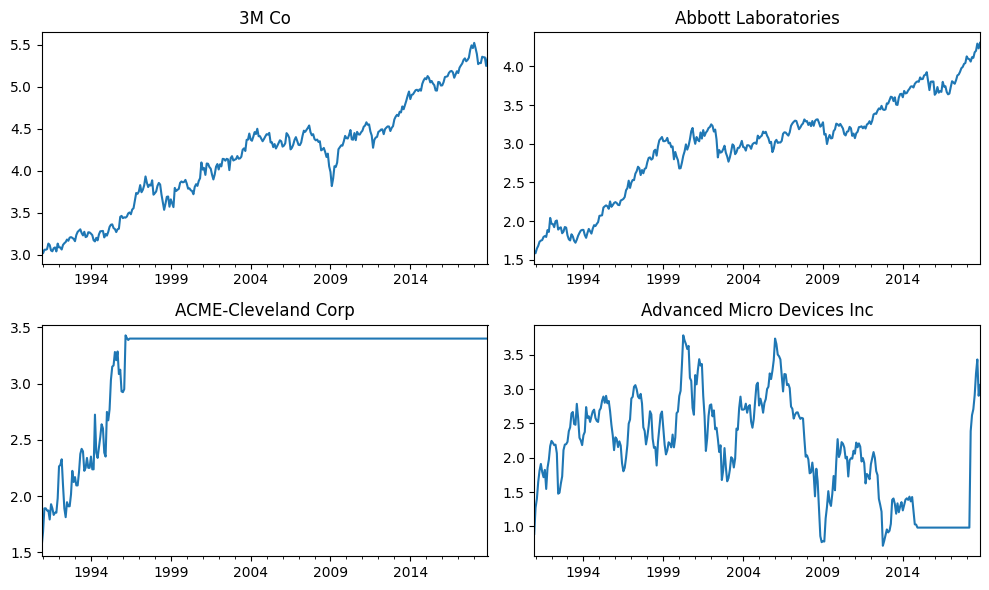

In [62]:
sample_tickers = log_prices.columns[:4]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, ticker in zip(axes.flatten(), sample_tickers):
    log_prices[ticker].plot(ax=ax)
    ax.set_title(ticker_to_name.get(ticker, ticker))
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [63]:
flat_threshold = 12  # months

def max_consecutive_flat(series):
    clean = series.dropna()
    diffs = clean.diff().dropna()
    is_flat = (diffs == 0)
    
    max_run = 0
    current_run = 0
    for flat in is_flat:
        if flat:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0
    return max_run

flat_runs = log_prices.apply(max_consecutive_flat)
suspicious = flat_runs[flat_runs >= flat_threshold]
print(f"Stocks with {flat_threshold}+ consecutive flat months: {len(suspicious)}")
print(suspicious.sort_values(ascending=False).head(10))

Stocks with 12+ consecutive flat months: 655
3123863Q UN Equity    330
643319Q UN Equity     328
1503Q UN Equity       326
HBJ UN Equity         325
1708Q US Equity       325
601964Q US Equity     323
292356Z US Equity     323
BAC1 US Equity        319
AZA UA Equity         318
BF/B UA Equity        313
dtype: int64


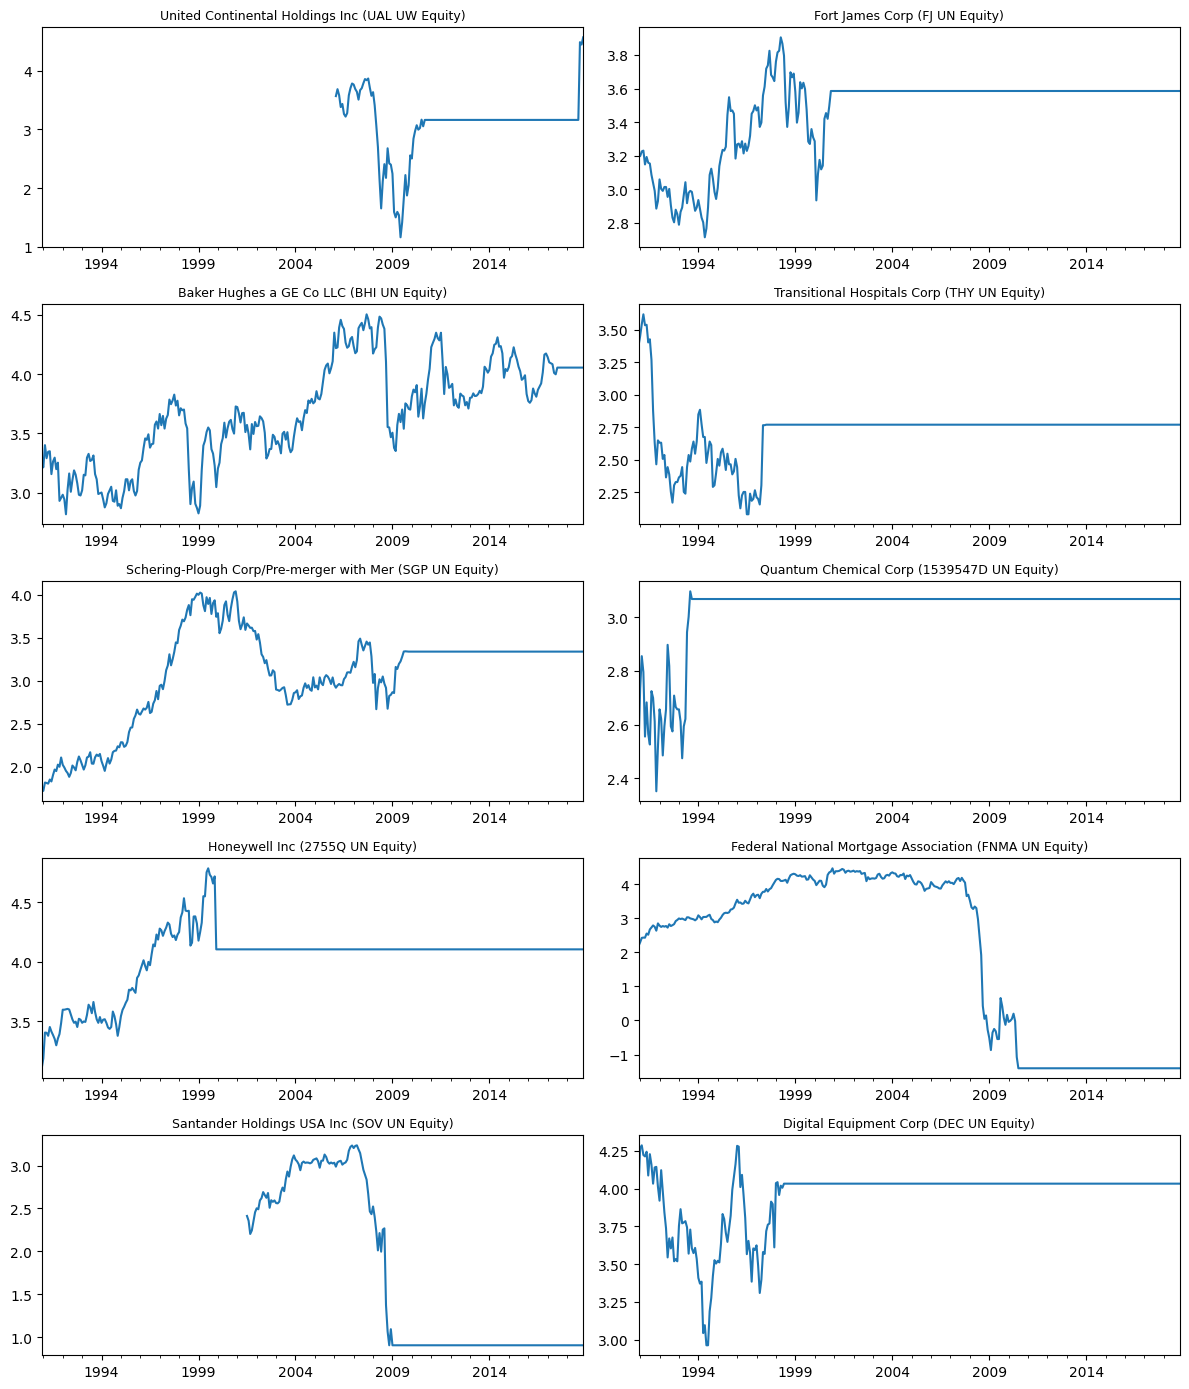

In [64]:
import random

random.seed(42)
sample_suspicious = random.sample(list(suspicious.index), 10)

fig, axes = plt.subplots(5, 2, figsize=(12, 14))

for ax, ticker in zip(axes.flatten(), sample_suspicious):
    log_prices[ticker].plot(ax=ax)
    ax.set_title(f"{ticker_to_name.get(ticker, ticker)} ({ticker})", fontsize=9)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

-------
### **Detecting forward-filled prices after delisting**

The visual inspection above reveals a systematic data quality issue: a large share of 
stocks (655 out of 1,260, roughly 52%) exhibit long runs of perfectly constant log-prices. 
Inspecting a random sample of these stocks shows a consistent pattern — companies known 
to have been delisted through M&A (e.g. Fort James Corp, Schering-Plough, Quantum 
Chemical, Digital Equipment Corp) show normal price movement up to their delisting date, 
followed by a perfectly flat line that continues until the end of the sample (November 
2018). This is consistent with the last available price being forward-filled instead of 
being recorded as missing.

This is a serious issue for our purposes: a spread between two artificially flat series 
is trivially stationary, which would generate spurious "cointegrated" pairs that have no 
economic meaning whatsoever.

**Detection criterion.** We distinguish a genuine flat period (e.g. a temporarily illiquid 
stock) from a forward-fill artifact using two facts: (i) a forward-filled value repeats 
*indefinitely*, for as long as the series continues, whereas a real market coincidence of 
unchanged prices across consecutive months is rare and does not sustain itself for long; 
and (ii) forward-fill artifacts run all the way to the last available observation for that 
stock, rather than being an isolated flat segment followed by a resumption of normal price 
movement. We therefore flag a stock as forward-filled if it has a flat run of at least 12 
consecutive months *that extends to the end of its available series*.

**Known limitations of this criterion**, which we explicitly acknowledge:
- A stock that is delisted, forward-filled, and later genuinely re-listed (e.g. after a 
  bankruptcy restructuring) would not be caught by condition (ii), since the flat segment 
  does not run to the end of the series. The case of United Continental Holdings (UAL), 
  visible in the sample above, is a plausible example.
- The 12-month threshold is a judgment call, not a fact derived from the data; it could 
  in principle misclassify both directions (a genuinely illiquid stock flagged as an 
  artifact, or a short forward-fill segment left uncorrected).
- We have no explicit "active/delisted" flag in the dataset, so delisting is inferred 
  indirectly from price behavior rather than observed directly.
- A stock delisted only a few months before the end of the sample would have a short 
  forward-fill run, possibly below our 12-month threshold, and would go undetected.

In [65]:
flat_threshold = 12

def detect_forward_fill_start(series):
    clean = series.dropna()
    if len(clean) < flat_threshold:
        return None
    
    diffs = clean.diff()
    
    is_flat = (diffs == 0)
    
    flat_run = 0
    flat_start_date = None
    
    for date in clean.index:
        if pd.isna(diffs.loc[date]):
            flat_run = 0
            flat_start_date = None
            continue
        
        if is_flat.loc[date]:
            if flat_run == 0:
                flat_start_date = date
            flat_run += 1
        else:
            flat_run = 0
            flat_start_date = None
    
    if flat_run >= flat_threshold:
        return flat_start_date
    else:
        return None

In [66]:
log_prices_raw = np.log(prices)

forward_fill_starts = {}

for ticker in log_prices_raw.columns:
    start_date = detect_forward_fill_start(log_prices_raw[ticker])
    if start_date is not None:
        forward_fill_starts[ticker] = start_date

print(f"Stocks flagged with forward-fill artifact: {len(forward_fill_starts)} out of {log_prices_raw.shape[1]}")

Stocks flagged with forward-fill artifact: 623 out of 1355


In [67]:
#set as NAN where forward filled
log_prices_clean = log_prices_raw.copy()

for ticker, start_date in forward_fill_starts.items():
    log_prices_clean.loc[start_date:, ticker] = np.nan

print(f"Total valid observations before fix: {log_prices_raw.notna().sum().sum()}")
print(f"Total valid observations after fix: {log_prices_clean.notna().sum().sum()}")
print(f"abs difference of: {abs(log_prices_raw.notna().sum().sum() - log_prices_clean.notna().sum().sum())}")

Total valid observations before fix: 389288
Total valid observations after fix: 289588
abs difference of: 99700


### Magnitude of the correction

The forward-fill correction removes 99,700 observations out of 389,288 (25.6% of the 
entire dataset), confirming that this was not a marginal data quality issue but a 
systematic artifact affecting a substantial share of the sample. This reinforces the 
importance of having caught it before proceeding to pair selection: leaving these 
artificial flat periods in place would have produced a large number of spurious 
"cointegrated" pairs with no economic content.

In [68]:
#new check for availability 

availability_clean = log_prices_clean.notna().sum(axis=0)

print(availability_clean.describe())
print("\n")
for threshold in [60, 120, 180, 240, 300]:
    n_stocks = (availability_clean >= threshold).sum()
    print(f"Threshold {threshold} months: {n_stocks} stocks remain")

count    1355.000000
mean      213.718081
std       106.256345
min         1.000000
25%       115.000000
50%       228.000000
75%       336.000000
max       336.000000
dtype: float64


Threshold 60 months: 1228 stocks remain
Threshold 120 months: 1004 stocks remain
Threshold 180 months: 827 stocks remain
Threshold 240 months: 644 stocks remain
Threshold 300 months: 452 stocks remain


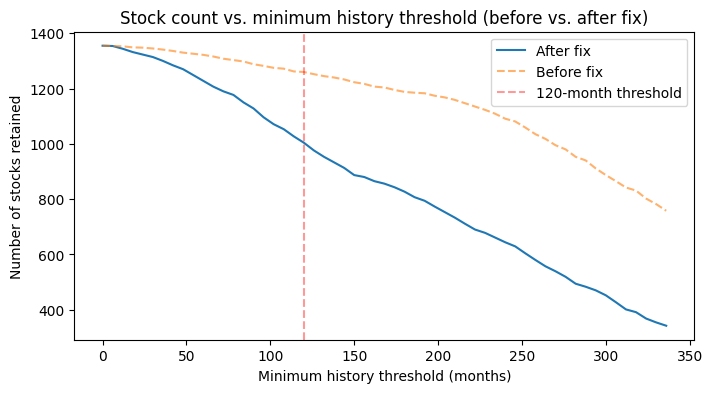

In [69]:
thresholds = range(0, 337, 6)
n_remaining_clean = [(availability_clean >= t).sum() for t in thresholds]

plt.figure(figsize=(8,4))
plt.plot(thresholds, n_remaining_clean, label='After fix')
plt.plot(thresholds, n_remaining, label='Before fix', linestyle='--', alpha=0.6)
plt.axvline(120, color='red', linestyle='--', alpha=0.4, label='120-month threshold')
plt.xlabel("Minimum history threshold (months)")
plt.ylabel("Number of stocks retained")
plt.title("Stock count vs. minimum history threshold (before vs. after fix)")
plt.legend()
plt.show()

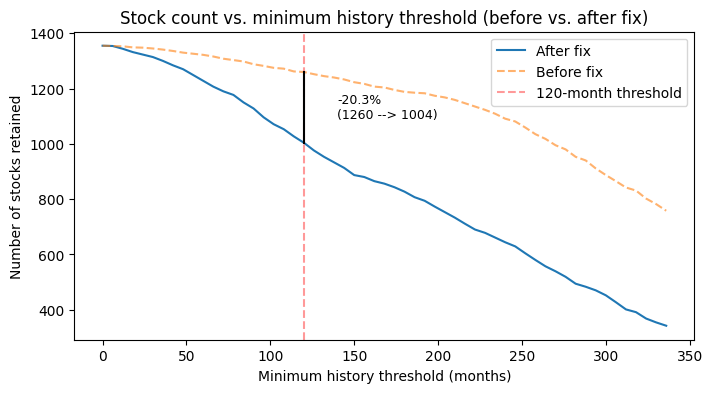

In [70]:
#fancy plot
thresholds = range(0, 337, 6)
n_remaining_clean = [(availability_clean >= t).sum() for t in thresholds]

plt.figure(figsize=(8,4))
plt.plot(thresholds, n_remaining_clean, label='After fix')
plt.plot(thresholds, n_remaining, label='Before fix', linestyle='--', alpha=0.6)
plt.axvline(120, color='red', linestyle='--', alpha=0.4, label='120-month threshold')

n_before = (availability >= 120).sum()
n_after = (availability_clean >= 120).sum()
pct_loss = (n_before - n_after) / n_before * 100

plt.plot([120, 120], [n_after, n_before], color='black', linewidth=1.5)
plt.annotate(
    f"-{pct_loss:.1f}%\n({n_before} --> {n_after})",
    xy=(120, (n_before + n_after) / 2),
    xytext=(140, (n_before + n_after) / 2),
    fontsize=9,
    va='center'
)

plt.xlabel("Minimum history threshold (months)")
plt.ylabel("Number of stocks retained")
plt.title("Stock count vs. minimum history threshold (before vs. after fix)")
plt.legend()
plt.show()

In [71]:
min_history = 120
selected_tickers_final = availability_clean[availability_clean >= min_history].index
log_prices_final = log_prices_clean[selected_tickers_final]

print(f"Final universe: {log_prices_final.shape[1]} stocks, {log_prices_final.shape[0]} months")

Final universe: 1004 stocks, 336 months


### Choice of minimum history threshold (revised after forward-fill correction)

We initially selected stocks using a 120-month minimum history threshold applied to the 
raw data, retaining 1,260 stocks. After identifying and correcting the forward-fill 
artifact (see above), we recompute data availability on the cleaned series and re-apply 
the same 120-month threshold, this time on genuine (non-artificial) price history. This 
retains 1,004 stocks — a 20.3% reduction from the initial count, entirely attributable 
to stocks whose apparent history was inflated by forward-filled prices.

We keep the same 120-month threshold rather than re-optimizing it, since the underlying 
rationale (covering multiple independent formation + trading cycles) is unaffected by 
the correction; what changes is which stocks satisfy it. The resulting universe of 1,004 
stocks remains large enough to support a statistically meaningful pair-selection step.

In [72]:
log_returns_final = log_prices_final.diff()

print(log_prices_final.shape)
print(log_returns_final.shape)

print(f"Valid log-price observations: {log_prices_final.notna().sum().sum()}")
print(f"Valid log-return observations: {log_returns_final.notna().sum().sum()}")

(336, 1004)
(336, 1004)
Valid log-price observations: 264659
Valid log-return observations: 263655


In [73]:
internal_gaps_count_final = 0

for ticker in log_prices_final.columns:
    series = log_prices_final[ticker]
    
    valid_indices = series[series.notna()].index
    first_date = valid_indices[0]
    last_date = valid_indices[-1]
    
    middle_part = series.loc[first_date:last_date]
    
    if middle_part.isna().sum() > 0:
        internal_gaps_count_final += 1

print(f"Stocks with internal gaps: {internal_gaps_count_final} out of {log_prices_final.shape[1]}")

Stocks with internal gaps: 0 out of 1004


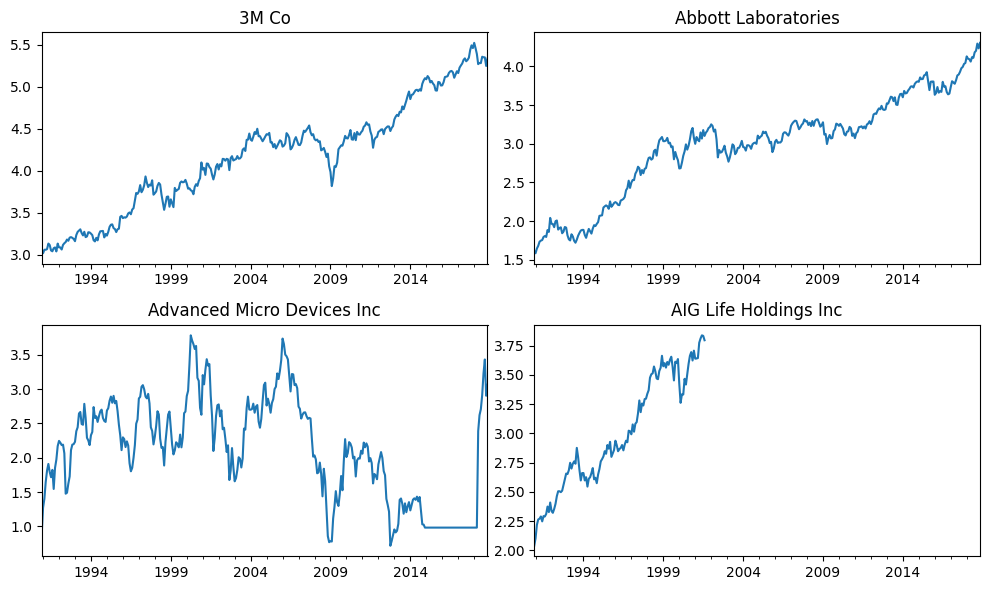

In [74]:
sample_tickers_final = log_prices_final.columns[:4]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, ticker in zip(axes.flatten(), sample_tickers_final):
    log_prices_final[ticker].plot(ax=ax)
    ax.set_title(ticker_to_name.get(ticker, ticker))
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [75]:
amd = log_prices_final["AMD UN Equity"]
diffs_amd = amd.diff()
flat_amd = (diffs_amd == 0)

print(flat_amd[flat_amd].index)

DatetimeIndex(['2015-01-30', '2015-02-27', '2015-03-31', '2015-04-30',
               '2015-05-29', '2015-06-30', '2015-07-31', '2015-08-31',
               '2015-09-30', '2015-10-30', '2015-11-30', '2015-12-31',
               '2016-01-29', '2016-02-29', '2016-03-31', '2016-04-29',
               '2016-05-31', '2016-06-30', '2016-07-29', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2016-12-30',
               '2017-01-31', '2017-02-28', '2017-03-31', '2017-04-28',
               '2017-05-31', '2017-06-30', '2017-07-31', '2017-08-31',
               '2017-09-29', '2017-10-31', '2017-11-30', '2017-12-29',
               '2018-01-31', '2018-02-28', '2018-03-30'],
              dtype='datetime64[ns]', freq=None)


In [76]:
log_prices_final.to_csv("log_prices_final.csv")
log_returns_final.to_csv("log_returns_final.csv")

import json
with open("ticker_to_name.json", "w") as f:
    json.dump(ticker_to_name, f)

## Block 1 — Data loading and cleaning: summary

We loaded the monthly price series for the S&P500 universe (336 months, December 1990 
to November 2018, 1,355 stocks) and converted it to log-prices. An initial history-based 
filter (minimum 120 months of data) retained 1,260 stocks.

Visual inspection of sample stocks revealed a systematic data quality issue: a large 
share of the dataset (623 stocks, 46% of the raw universe) had prices artificially 
forward-filled after delisting — the last available price was repeated indefinitely 
instead of being recorded as missing. This was confirmed by cross-checking flagged 
tickers against known M&A delistings (Fort James, Schering-Plough, Quantum Chemical, 
Digital Equipment, among others).

We built a detection rule flagging any flat run of at least 12 consecutive months that 
extends to the last available observation of a stock, and corrected the issue by setting 
those values back to missing. This removed 99,700 observations (25.6% of the dataset) — 
confirming the scale of the problem was material, not marginal.

Since the original history filter had been computed on contaminated data, we recomputed 
data availability on the cleaned series and re-applied the same 120-month threshold, 
landing on a **final universe of 1,004 stocks**, a 20.3% reduction from the initial 1,260.

We explicitly acknowledge a known limitation of our detection rule: it only catches flat 
runs that persist until the end of a stock's series, and therefore misses forward-fill 
artifacts followed by a genuine resumption of trading. We found a concrete instance of 
this in our final universe: Advanced Micro Devices (AMD) shows a 39-month flat run 
(January 2015–April 2018) that our rule does not flag, since prices resume moving 
afterward. We chose to accept this limitation rather than relax the detection criterion, 
given the time constraints of the project and the expected low incidence of this 
specific pattern.

A final check confirmed zero internal gaps in the cleaned, filtered universe — all 
remaining missing values sit at the edges of each series (pre-listing or post-delisting), 
consistent with normal index turnover rather than data errors.

**Final outputs of this block:** `log_prices_final` and `log_returns_final` 
(336 months × 1,004 stocks), ready for pair selection in Block 2.

----------
## **BLOCK 2 - Pair selection via cointegration** 


This block implements the core statistical step of the strategy: identifying pairs of 
stocks whose price relationship is stationary (cointegrated), which is the theoretical 
foundation for expecting their spread to mean-revert.

We follow a rolling, two-phase structure for the entire backtest period:

- **Formation period** (12 months): used to select candidate pairs via cointegration 
  testing and to estimate the parameters needed for trading — the hedge ratio $\hat\beta$ 
  from the cointegration regression, and the spread's mean $\mu_S$ and standard 
  deviation $\sigma_S$ used to compute the z-score signal.
- **Trading period** (6 months): the period immediately following formation, over which 
  the estimated parameters are applied out-of-sample to generate trading signals and 
  simulate positions. No re-estimation happens within this window.

This mirrors a train/test split familiar from statistical modeling, with one important 
distinction: success in the trading period is not measured by a prediction error metric, 
but by simulating the actual profit and loss generated by the trading rule.

The formation/trading window rolls forward through the full sample in non-overlapping 
6-month steps (the length of the trading period), so that consecutive trading periods 
never overlap with each other, while each new formation period absorbs the trading 
period of the previous cycle. This produces multiple independent trading cycles across 
the 1991–2018 sample rather than relying on a single formation/trading split.

This step only concerns the time structure of the backtest (which dates belong to which 
phase). The actual data used within each cycle will be: log-prices for the cointegration 
regression and spread construction, and log-returns later for risk and performance 
metrics (volatility, Sharpe ratio) — not for pair selection itself.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

log_prices_final = pd.read_csv("log_prices_final.csv", index_col=0, parse_dates=True)
log_returns_final = pd.read_csv("log_returns_final.csv", index_col=0, parse_dates=True)

with open("ticker_to_name.json") as f:
    ticker_to_name = json.load(f)

print(log_prices_final.shape)
print(log_returns_final.shape)
print(len(ticker_to_name))

(336, 1004)
(336, 1004)
1355


In [78]:
formation_months = 12
trading_months = 6

dates = log_prices_final.index
n_months = len(dates)

cycles = []
start_idx = 0

while start_idx + formation_months + trading_months <= n_months:
    formation_start = dates[start_idx]
    formation_end = dates[start_idx + formation_months - 1]
    trading_start = dates[start_idx + formation_months]
    trading_end = dates[start_idx + formation_months + trading_months - 1]
    
    cycles.append({
        "formation_start": formation_start,
        "formation_end": formation_end,
        "trading_start": trading_start,
        "trading_end": trading_end
    })
    
    start_idx += trading_months

cycles_df = pd.DataFrame(cycles)
print(f"Number of cycles: {len(cycles_df)}")
display(cycles_df.head())
print("\n")
print(cycles_df.iloc[-1])
print(dates[-1])

Number of cycles: 54


,formation_start,formation_end,trading_start,trading_end
0,1990-12-31,1991-11-29,1991-12-31,1992-05-29
1,1991-06-28,1992-05-29,1992-06-30,1992-11-30
2,1991-12-31,1992-11-30,1992-12-31,1993-05-31
3,1992-06-30,1993-05-31,1993-06-30,1993-11-30
4,1992-12-31,1993-11-30,1993-12-31,1994-05-31




formation_start   2017-06-30
formation_end     2018-05-31
trading_start     2018-06-29
trading_end       2018-11-30
Name: 53, dtype: datetime64[ns]
2018-11-30 00:00:00


### Rolling cycle structure — result

Rolling the formation (12-month) and trading (6-month) windows forward in non-overlapping 
6-month steps across the full 1990-12 to 2018-11 sample produces **54 independent trading 
cycles**. The last cycle's trading period ends exactly on the last available date in the 
dataset (2018-11-30), confirming the rolling logic correctly exhausts the sample without 
generating an incomplete final cycle.

### PROVA 

(12, 1004)
3M Co / Abbott Laboratories
0 0
const            2.840427
ABT UN Equity    0.127976
dtype: float64
                            OLS Regression Results                            
Dep. Variable:          MMM UN Equity   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     1.421
Date:                Wed, 17 Jun 2026   Prob (F-statistic):              0.261
Time:                        15:42:12   Log-Likelihood:                 24.752
No. Observations:                  12   AIC:                            -45.50
Df Residuals:                      10   BIC:                            -44.53
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------

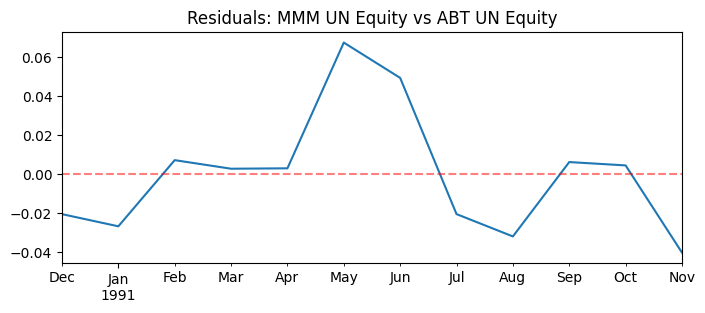

ADF statistic: -1.2133
p-value: 0.6679
Critical values: {'1%': -4.9386902332361515, '5%': -3.477582857142857, '10%': -2.8438679591836733}
{'stock_A': 'MMM UN Equity', 'stock_B': 'ABT UN Equity', 'alpha': 2.840427319298597, 'beta': 0.1279760052335357, 'adf_pvalue': 0.6678593187875476}


In [79]:
# --- Cella 1: estrazione finestra di formation per il ciclo 0 ---
cycle0 = cycles_df.iloc[0]
formation_data = log_prices_final.loc[cycle0["formation_start"]:cycle0["formation_end"]]
print(formation_data.shape)
formation_data.head()

# --- Cella 2: scegliere una coppia di prova ---
stock_A = formation_data.columns[0]
stock_B = formation_data.columns[1]

print(ticker_to_name.get(stock_A), "/", ticker_to_name.get(stock_B))

y = formation_data[stock_A]
x = formation_data[stock_B]

print(y.isna().sum(), x.isna().sum()) 

# --- Cella 3: regressione di cointegrazione (OLS) ---
import statsmodels.api as sm

x_with_const = sm.add_constant(x)

model = sm.OLS(y, x_with_const)
results = model.fit()

print(results.params)
print(results.summary())

# --- Cella 4: residui della regressione ---
residuals = results.resid

residuals.plot(figsize=(8,3), title=f"Residuals: {stock_A} vs {stock_B}")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# --- Cella 5: ADF test sui residui ---
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(residuals)

print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Critical values: {adf_result[4]}")

# --- Cella 6: funzione generale per testare una coppia ---
def test_pair_cointegration(stock_A, stock_B, formation_data):
    y = formation_data[stock_A]
    x = formation_data[stock_B]
    
    if y.isna().sum() > 0 or x.isna().sum() > 0:
        return None
    
    if x.std() == 0 or y.std() == 0:
        return None
    
    x_with_const = sm.add_constant(x)
    model = sm.OLS(y, x_with_const)
    results = model.fit()
    
    beta = results.params[stock_B]
    alpha = results.params["const"]
    
    residuals = results.resid
    adf_result = adfuller(residuals)
    p_value = adf_result[1]
    
    return {
        "stock_A": stock_A,
        "stock_B": stock_B,
        "alpha": alpha,
        "beta": beta,
        "adf_pvalue": p_value
    }

# --- Cella 7: verifica della funzione sul caso noto ---
test_result = test_pair_cointegration(stock_A, stock_B, formation_data)
print(test_result)



### FINE PROVA

In [80]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [89]:
def test_pair_cointegration(stock_A, stock_B, formation_data, std_threshold=1e-8):
    y = formation_data[stock_A]
    x = formation_data[stock_B]
    
    if y.isna().sum() > 0 or x.isna().sum() > 0:
        return None
    
    if x.std() < std_threshold or y.std() < std_threshold:
        return None
    
    x_with_const = sm.add_constant(x)
    model = sm.OLS(y, x_with_const)
    results = model.fit()
    
    beta = results.params[stock_B]
    alpha = results.params["const"]
    
    residuals = results.resid
    adf_result = adfuller(residuals)
    p_value = adf_result[1]
    
    return {
        "stock_A": stock_A,
        "stock_B": stock_B,
        "alpha": alpha,
        "beta": beta,
        "adf_pvalue": p_value
    }

### Restricting pair search to intra-sector combinations 


Testing all possible pairs in the 1,004-stock universe would require evaluating 
$\binom{1004}{2} \approx 503{,}500$ cointegration tests per formation cycle. At a 
standard significance level, this would produce tens of thousands of false positives 
by chance alone — a clear multiple testing problem that must be addressed before any 
meaningful pair selection can take place.

We restrict the search space by only testing pairs of stocks belonging to the same 
GICS sector, using the sector sheets provided in the original dataset (Energy, 
Technology, Financial, etc.). This serves two purposes: it sharply reduces the number 
of pairs tested — and therefore the severity of the multiple testing correction needed 
downstream — and it is economically motivated, since stocks in the same sector are more 
likely to share common fundamental drivers that could justify a genuine cointegrating 
relationship, rather than a spurious statistical artifact.

We build a `{sector: [tickers]}` mapping from the sector sheets, restricted to the 
1,004 stocks in our final universe, and verify that every stock is assigned to exactly 
one sector before proceeding.

In [82]:
sector_sheets = ["Energy", "Communications", "Consumer, Non-cyclical", "Industrial", 
                  "Financial", "Consumer, Cyclical", "Technology", "Utilities", 
                  "Basic Materials", "Diversified"]

sector_to_tickers = {}

for sector in sector_sheets:
    df_sector = pd.read_excel("SPX500Original.xlsm", sheet_name=sector, header=[0,1], index_col=0, engine="openpyxl")
    df_sector.columns = df_sector.columns.get_level_values(0)
    
    flagged = (df_sector == 1).any(axis=0)
    tickers_in_sector = flagged[flagged].index.tolist()
    
    sector_to_tickers[sector] = tickers_in_sector

for sector, tickers in sector_to_tickers.items():
    print(f"{sector}: {len(tickers)} stocks")

Energy: 96 stocks
Communications: 141 stocks
Consumer, Non-cyclical: 256 stocks
Industrial: 165 stocks
Financial: 228 stocks
Consumer, Cyclical: 185 stocks
Technology: 152 stocks
Utilities: 61 stocks
Basic Materials: 69 stocks
Diversified: 1 stocks


In [83]:
final_universe = set(log_prices_final.columns)

sector_to_tickers_filtered = {
    sector: [t for t in tickers if t in final_universe]
    for sector, tickers in sector_to_tickers.items()
}

for sector, tickers in sector_to_tickers_filtered.items():
    print(f"{sector}: {len(tickers)} stocks")

total_assigned = sum(len(t) for t in sector_to_tickers_filtered.values())
print(f"\nTotal stocks assigned to a sector: {total_assigned} (universe size: {len(final_universe)})")

Energy: 69 stocks
Communications: 101 stocks
Consumer, Non-cyclical: 192 stocks
Industrial: 118 stocks
Financial: 180 stocks
Consumer, Cyclical: 131 stocks
Technology: 118 stocks
Utilities: 44 stocks
Basic Materials: 50 stocks
Diversified: 1 stocks

Total stocks assigned to a sector: 1004 (universe size: 1004)


### Sector mapping — result

All 1,004 stocks in the final universe are assigned to exactly one of the ten sectors, 
with no orphaned or duplicated assignments. Sector sizes range widely, from 192 stocks 
in Consumer Non-cyclical to just 1 stock in Diversified — a residual category (likely 
conglomerates) too small to form any intra-sector pair. This stock will therefore not 
appear in any candidate pair under our intra-sector restriction, which we note as a 
minor, acceptable consequence of this design choice.

In [84]:
from math import comb

total_pairs_unrestricted = comb(len(final_universe), 2)
total_pairs_intra_sector = sum(comb(len(t), 2) for t in sector_to_tickers_filtered.values())

print(f"Unrestricted pairs: {total_pairs_unrestricted}")
print(f"Intra-sector pairs: {total_pairs_intra_sector}")
print(f"Reduction: {(1 - total_pairs_intra_sector/total_pairs_unrestricted)*100:.1f}%")

Unrestricted pairs: 503506
Intra-sector pairs: 66334
Reduction: 86.8%


### Effect of intra-sector restriction on candidate pairs

Restricting candidate pairs to intra-sector combinations reduces the search space from 
503,506 (all possible pairs) to 66,334 — an 86.8% reduction. This substantially lowers 
the severity of the multiple testing correction needed in the next step, while keeping 
the search space large enough for a statistically meaningful pair-selection process.

### Note on multiple testing and the reference paper

Gatev et al. (2006) do not face this multiple testing problem in their original 
methodology, since they select pairs via the distance method (minimizing Euclidean 
distance between normalized cumulative return indices) rather than via a formal 
statistical test. There is no p-value, and therefore no significance threshold to 
correct, in their approach.

Since we adopt the cointegration-based approach (Engle-Granger), which does rely on a 
formal hypothesis test, we face a genuine multiple testing problem that has no direct 
precedent in the reference paper. We address it independently, drawing on standard 
econometric practice for multiple hypothesis testing (Bonferroni or Benjamini-Hochberg 
correction) rather than on Gatev et al.'s methodology.

### Multiple testing correction — choice of method

With 66,334 candidate pairs tested per formation cycle, applying the conventional 
$\alpha = 0.05$ threshold uncorrected would yield over 3,000 false positives by chance 
alone, regardless of whether any true cointegrating relationship exists. A correction 
for multiple testing is therefore necessary.

We considered two standard approaches:

- **Bonferroni correction**: divides $\alpha$ by the number of tests 
  ($\alpha_{corrected} = 0.05 / 66{,}334 \approx 7.5 \times 10^{-7}$), controlling the 
  probability of even a single false positive across the entire set of tests. This is 
  very conservative and risks rejecting too many true cointegrating pairs (low 
  statistical power), potentially leaving very few — or no — pairs selected.
- **Benjamini-Hochberg (FDR) correction**: controls the expected *proportion* of false 
  positives among the pairs declared significant (e.g. "at most 5% of selected pairs 
  are false positives"), rather than eliminating false positives entirely. This retains 
  more statistical power while still addressing the multiple testing problem.

Note that the reference paper (Gatev et al., 2006) provides no guidance here, since their 
pair selection is based on the distance method (minimizing Euclidean distance between 
normalized price series), which involves no hypothesis test and therefore no multiple 
testing problem. This choice is made independently, based on standard econometric 
practice for multiple hypothesis testing.

We adopt the **Benjamini-Hochberg procedure** at a false discovery rate of 5%, as it is 
better suited to a setting with a large number of tests where some power to detect true 
cointegrating relationships needs to be preserved, rather than guaranteeing zero false 
positives at the cost of potentially discarding most or all genuine pairs.

In [85]:
cycle0 = cycles_df.iloc[0]
formation_data = log_prices_final.loc[cycle0["formation_start"]:cycle0["formation_end"]]

print(formation_data.shape)

(12, 1004)


In [91]:
from itertools import combinations

all_results = []

for sector, tickers in sector_to_tickers_filtered.items():
    pairs = list(combinations(tickers, 2))
    
    for stock_A, stock_B in pairs:
        result = test_pair_cointegration(stock_A, stock_B, formation_data)
        if result is not None:
            result["sector"] = sector
            all_results.append(result)

results_df = pd.DataFrame(all_results)
print(f"Pairs successfully tested: {len(results_df)} out of {total_pairs_intra_sector} candidate pairs")
results_df.head()

/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


Pairs successfully tested: 22147 out of 66334 candidate pairs


,stock_A,stock_B,alpha,beta,adf_pvalue,sector
0,AVP UN Equity,CL UN Equity,-0.116656,1.100252,0.060897,Energy
1,AVP UN Equity,CAG UN Equity,-2.153405,1.567156,0.907689,Energy
2,AVP UN Equity,GLW UN Equity,0.473335,0.537010,0.584335,Energy
3,AVP UN Equity,DD UN Equity,-0.534776,0.720713,0.996327,Energy
4,AVP UN Equity,CGP UN Equity,0.260209,0.501249,0.418818,Energy


### **ALARM --> SECTOR CLASSIFICATION IS NOT CORRECT**

In [93]:
for sector, tickers in sector_to_tickers_filtered.items():
    if "AVP UN Equity" in tickers:
        print(sector)

Energy


In [94]:
mismatches = []

for sector, tickers in sector_to_tickers_filtered.items():
    for ticker in tickers:
        name = ticker_to_name.get(ticker, "")
        mismatches.append({"ticker": ticker, "name": name, "assigned_sector": sector})

mismatch_df = pd.DataFrame(mismatches)
mismatch_df[mismatch_df["assigned_sector"] == "Energy"].head(20)

,ticker,name,assigned_sector
0,AVP UN Equity,Avon Products Inc,Energy
1,CL UN Equity,Colgate-Palmolive Co,Energy
2,CAG UN Equity,Conagra Brands Inc,Energy
3,GLW UN Equity,Corning Inc,Energy
4,DD UN Equity,EI du Pont de Nemours & Co,Energy
5,CGP UN Equity,El Paso CGP Co LLC,Energy
6,TXU US Equity,Energy Future Holdings Corp/Old,Energy
7,EXC UN Equity,Exelon Corp,Energy
8,HRB UN Equity,H&R Block Inc,Energy
9,HAS US Equity,Hasbro Inc,Energy


In [98]:
# Cerchiamo se Exxon è nell'universo e in che sheet risulta
candidates = [t for t in ticker_to_name if "Exxon" in ticker_to_name.get(t, "") or "Chevron" in ticker_to_name.get(t, "")]
print(candidates)

for ticker in candidates:
    for sector in sector_sheets:
        df_check = pd.read_excel("SPX500Original.xlsm", sheet_name=sector, header=[0,1], index_col=0, engine="openpyxl")
        df_check.columns = df_check.columns.get_level_values(0)
        if ticker in df_check.columns:
            val = df_check[ticker].iloc[5]
            if val == 1:
                print(f"{ticker} ({ticker_to_name[ticker]}) -> {sector}")

['CVX UN Equity', 'XOM UN Equity']
CVX UN Equity (Chevron Corp) -> Consumer, Cyclical
XOM UN Equity (Exxon Mobil Corp) -> Consumer, Cyclical


In [100]:
known_companies = {
    "XOM UN Equity": "Energy (expected)",
    "ORCL UQ Equity": "Technology (expected)",
    "JPM UN Equity": "Financial (expected)",
    "T UN Equity": "Communications (expected)",
}

for ticker, expected in known_companies.items():
    for sector in sector_sheets:
        df_check = pd.read_excel("SPX500Original.xlsm", sheet_name=sector, header=[0,1], index_col=0, engine="openpyxl")
        df_check.columns = df_check.columns.get_level_values(0)
        if ticker in df_check.columns:
            val = df_check[ticker].iloc[5]
            if val == 1:
                print(f"{ticker} ({expected}) -> actually in: {sector}")

XOM UN Equity (Energy (expected)) -> actually in: Consumer, Cyclical
ORCL UQ Equity (Technology (expected)) -> actually in: Energy
JPM UN Equity (Financial (expected)) -> actually in: Industrial
T UN Equity (Communications (expected)) -> actually in: Communications


In [102]:
df_price_check = pd.read_excel("SPX500Original.xlsm", sheet_name="Price", header=[0,1], index_col=0, engine="openpyxl")
price_ticker_name = dict(zip(df_price_check.columns.get_level_values(0), df_price_check.columns.get_level_values(1)))

df_energy_raw = pd.read_excel("SPX500Original.xlsm", sheet_name="Energy", header=[0,1], index_col=0, engine="openpyxl")
energy_ticker_name = dict(zip(df_energy_raw.columns.get_level_values(0), df_energy_raw.columns.get_level_values(1)))

print("Price sheet - ORCL name:", price_ticker_name.get("ORCL UQ Equity"))
print("Energy sheet - ORCL name:", energy_ticker_name.get("ORCL UQ Equity"))

mismatches = 0
for ticker in price_ticker_name:
    if ticker in energy_ticker_name:
        if price_ticker_name[ticker] != energy_ticker_name[ticker]:
            mismatches += 1

print(f"\nTotal ticker/name mismatches between Price and Energy sheets: {mismatches}")

Price sheet - ORCL name: Oracle Corp
Energy sheet - ORCL name: Oracle Corp

Total ticker/name mismatches between Price and Energy sheets: 0


### **Abandoning the intra-sector restriction**

We initially planned to restrict candidate pairs to intra-sector combinations, using 
the sector sheets provided in the original dataset (Energy, Technology, Financial, 
etc.), both to reduce the multiple testing burden and on economic grounds (stocks in 
the same sector are more likely to share common fundamental drivers).

However, while testing pairs, we found that several well-known stocks are misclassified 
in these sheets. Most strikingly, Oracle Corp is flagged under "Energy," while Exxon 
Mobil and Chevron — companies whose sector membership is unambiguous — are flagged 
under "Consumer, Cyclical." We verified this is not a parsing issue on our side: ticker 
and company names match exactly between the `Price` sheet and each sector sheet (zero 
mismatches across the full universe), confirming that the flag values themselves, as 
provided in the original file, are unreliable. The pattern of misclassification is not 
a simple systematic shift (e.g. one sector sheet consistently mapped to another) but 
appears irregular, which means it cannot be corrected with a simple relabeling.

Given this, we cannot rely on the provided sector classification to restrict the 
candidate pair universe. We therefore revert to testing **all possible pairs** in the 
1,004-stock universe (503,506 candidate pairs per cycle), and rely entirely on the 
Benjamini-Hochberg correction to control the false discovery rate. This is more 
computationally demanding and forgoes the economic motivation that sector restriction 
would have provided, but avoids building the pair selection step on a data field we 
have shown to be unreliable.

In [103]:
all_results = []
failed_pairs = []

all_tickers = list(log_prices_final.columns)
pairs = list(combinations(all_tickers, 2))

print(f"Total pairs to test: {len(pairs)}")

for stock_A, stock_B in pairs:
    try:
        result = test_pair_cointegration(stock_A, stock_B, formation_data)
        if result is not None:
            all_results.append(result)
    except Exception as e:
        failed_pairs.append((stock_A, stock_B, str(e)))

results_df = pd.DataFrame(all_results)
print(f"Pairs successfully tested: {len(results_df)} out of {len(pairs)} candidate pairs")
print(f"Pairs that raised an error: {len(failed_pairs)}")
results_df.head()

Total pairs to test: 503506


/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regressi

Pairs successfully tested: 173750 out of 503506 candidate pairs
Pairs that raised an error: 5


,stock_A,stock_B,alpha,beta,adf_pvalue
0,MMM UN Equity,ABT UN Equity,2.840427,0.127976,6.678593e-01
1,MMM UN Equity,AMD UN Equity,2.969184,0.057643,4.426487e-01
2,MMM UN Equity,950967Q UN Equity,2.659781,0.179221,3.699201e-01
3,MMM UN Equity,APD UN Equity,2.221452,0.310649,3.776858e-09
4,MMM UN Equity,1281683D UN Equity,3.362065,-0.146821,1.582460e-01


In [104]:
print(failed_pairs)

[('BHI UN Equity', 'BHGE UN Equity', 'Invalid input, x is constant'), ('CMCSA UQ Equity', 'CMCSA UW Equity', 'Invalid input, x is constant'), ('TRV US Equity', 'TRV UN Equity', 'Invalid input, x is constant'), ('KLAC UQ Equity', 'KLAC UW Equity', 'Invalid input, x is constant'), ('ADCT UQ Equity', 'ADCT UW Equity', 'Invalid input, x is constant')]


### Pair testing — first cycle results

Testing all 503,506 candidate pairs in the first formation cycle, 173,750 pairs (34.5%) 
were successfully tested; the remainder were excluded due to missing data or near-zero 
variance in one of the two series within this specific 12-month window (consistent with 
residual forward-fill artifacts not fully caught by the Block 1 correction — see the 
AMD example discussed earlier). Only 5 pairs raised an unhandled error during testing 
and were discarded without further investigation, given the negligible impact on the 
overall result.

### Note on duplicate-stock pairs

The 5 pairs that raised an error during testing all share a common pattern: identical 
company name but different ticker suffixes (e.g. `CMCSA UQ Equity` vs `CMCSA UW Equity`, 
`TRV US Equity` vs `TRV UN Equity`). This suggests these are the same underlying company 
listed under two different ticker/exchange conventions in the dataset, rather than 
genuinely distinct stocks. Testing such a pair against itself produces a degenerate 
regression (perfect collinearity), which is why these specific pairs failed. We discard 
them, since they do not represent a meaningful candidate pair for the strategy.

In [105]:
from statsmodels.stats.multitest import multipletests

p_values = results_df["adf_pvalue"].values

reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

results_df["significant"] = reject
results_df["pvalue_corrected"] = pvals_corrected

n_significant = results_df["significant"].sum()
print(f"Pairs significant after Benjamini-Hochberg correction (FDR=5%): {n_significant} out of {len(results_df)}")

Pairs significant after Benjamini-Hochberg correction (FDR=5%): 39058 out of 173750


### Half-life as a second selection criterion

Statistical significance from the cointegration test (39,058 pairs after FDR correction) 
tells us a pair's spread is stationary, but says nothing about how fast it reverts to 
its mean. A pair can be statistically cointegrated yet revert so slowly that the spread 
would not complete even one full mean-reversion cycle within the 6-month trading period, 
making it unusable in practice despite being statistically valid.

We address this with the **half-life of mean reversion**, estimated by fitting an AR(1) 
model to the spread:

$$S_t = c + \phi S_{t-1} + \eta_t$$

The half-life — the expected time for a deviation from the mean to shrink by half — is 
then:

$$\text{half-life} = \frac{\ln(0.5)}{\ln(\phi)}$$

We discard pairs where $\phi$ falls outside $(0, 1)$, since these do not correspond to a 
sensible mean-reverting process (values $\geq 1$ imply non-stationary or explosive 
behavior; values $\leq 0$ imply oscillation that flips sign every period rather than 
smooth reversion). Among the remaining cointegrated pairs, we will favor those with a 
half-life short enough to be tradable within the 6-month trading window, combining the 
statistical (cointegration) and economic (speed of reversion) criteria for pair 
selection.

In [106]:
def compute_half_life(spread):
    spread_lag = spread.shift(1).dropna()
    spread_current = spread.loc[spread_lag.index]
    
    spread_lag_with_const = sm.add_constant(spread_lag)
    model = sm.OLS(spread_current, spread_lag_with_const)
    results = model.fit()
    
    phi = results.params.iloc[1]
    
    if phi <= 0 or phi >= 1:
        return None
    
    half_life = np.log(0.5) / np.log(phi)
    return half_life

In [107]:
half_lives = []

significant_pairs = results_df[results_df["significant"]].copy()

for idx, row in significant_pairs.iterrows():
    stock_A = row["stock_A"]
    stock_B = row["stock_B"]
    alpha = row["alpha"]
    beta = row["beta"]
    
    y = formation_data[stock_A]
    x = formation_data[stock_B]
    spread = y - alpha - beta * x
    
    hl = compute_half_life(spread)
    half_lives.append(hl)

significant_pairs["half_life"] = half_lives

print(significant_pairs["half_life"].describe())
print(f"\nPairs with invalid half-life (phi outside (0,1)): {significant_pairs['half_life'].isna().sum()}")

count    30494.000000
mean         1.263070
std          6.372952
min          0.072557
25%          0.493832
50%          0.819398
75%          1.304021
max        782.422568
Name: half_life, dtype: float64

Pairs with invalid half-life (phi outside (0,1)): 8564


Pairs with half-life <= 1 month: 18745
Pairs with half-life <= 3 months: 29210
Pairs with half-life <= 6 months: 30135
Pairs with half-life <= 12 months: 30364
Pairs with half-life > 12 months: 130


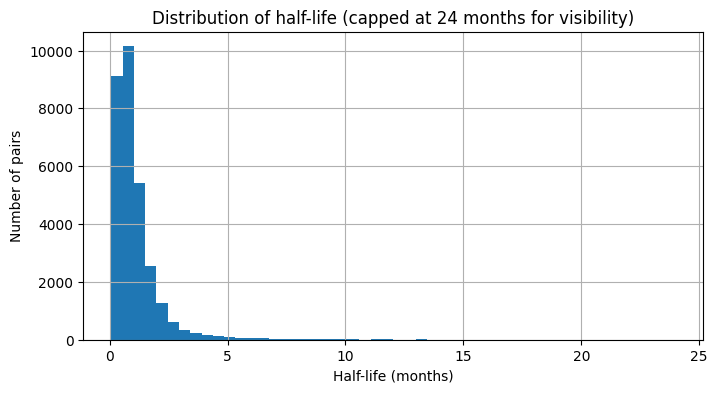

In [108]:
import matplotlib.pyplot as plt

valid_hl = significant_pairs["half_life"].dropna()

print(f"Pairs with half-life <= 1 month: {(valid_hl <= 1).sum()}")
print(f"Pairs with half-life <= 3 months: {(valid_hl <= 3).sum()}")
print(f"Pairs with half-life <= 6 months: {(valid_hl <= 6).sum()}")
print(f"Pairs with half-life <= 12 months: {(valid_hl <= 12).sum()}")
print(f"Pairs with half-life > 12 months: {(valid_hl > 12).sum()}")

valid_hl[valid_hl <= 24].hist(bins=50, figsize=(8,4))
plt.xlabel("Half-life (months)")
plt.ylabel("Number of pairs")
plt.title("Distribution of half-life (capped at 24 months for visibility)")
plt.show()

### Half-life threshold

We set a maximum acceptable half-life of 3 months, motivated by the 6-month trading 
period: this allows the spread enough time to complete at least one full mean-reversion 
cycle during trading, rather than merely beginning to revert. The distribution shows 
this threshold is not very restrictive in practice — 29,210 of the 30,494 pairs with a 
valid half-life (95.8%) already satisfy it — and mainly removes a small set of 
pathological cases (up to 782 months) where the AR(1) coefficient $\phi$ is so close to 
1 that mean reversion is, for practical purposes, negligible within any realistic 
trading horizon.

In [109]:
half_life_threshold = 3

final_candidates = significant_pairs[
    significant_pairs["half_life"].notna() & 
    (significant_pairs["half_life"] <= half_life_threshold)
].copy()

print(f"Final candidate pairs (cointegrated + half-life <= {half_life_threshold} months): {len(final_candidates)}")
final_candidates.sort_values("half_life").head(10)

Final candidate pairs (cointegrated + half-life <= 3 months): 29210


,stock_A,stock_B,alpha,beta,adf_pvalue,significant,pvalue_corrected,half_life
120776,RHDCQ UN Equity,ROL UN Equity,2.029500,0.072181,8.831723e-22,True,NaN,0.072557
78765,HM UN Equity,CTL UN Equity,2.339018,0.201537,2.692532e-03,True,NaN,0.076400
131270,SYY UN Equity,TIN UN Equity,-0.101802,0.680218,3.698048e-03,True,NaN,0.077196
137190,UTX UN Equity,WOR US Equity,2.008205,-0.095885,3.646876e-03,True,NaN,0.077688
12627,653707Q UN Equity,HAR UN Equity,3.030025,0.342211,1.656775e-06,True,NaN,0.078740
124449,3520842Q UN Equity,UPC UN Equity,3.532095,-0.224659,8.702365e-03,True,NaN,0.079498
161074,USB UN Equity,FDO UN Equity,0.486939,0.299546,3.440974e-04,True,NaN,0.081241
138125,USB US Equity,FDO UN Equity,0.486939,0.299546,3.440974e-04,True,NaN,0.081241
27948,BC UN Equity,UALAQ UN Equity,-1.965117,1.283913,0.000000e+00,True,NaN,0.082415
84136,ITT UN Equity,NL UN Equity,-0.136092,0.313194,6.781307e-03,True,NaN,0.087904


In [110]:
print(results_df["pvalue_corrected"].isna().sum())
print(results_df["pvalue_corrected"].head())

173750
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: pvalue_corrected, dtype: float64


In [111]:
print(results_df["adf_pvalue"].dtype)
print(results_df["adf_pvalue"].isna().sum())
print(results_df["adf_pvalue"].describe())

float64
1
count    173749.000000
mean          0.381099
std           0.374786
min           0.000000
25%           0.019644
50%           0.251936
75%           0.739795
max           1.000000
Name: adf_pvalue, dtype: float64


In [112]:
print(results_df[results_df["adf_pvalue"].isna()])

               stock_A         stock_B         alpha  beta  adf_pvalue  \
147347  JAVA UQ Equity  JAVA UW Equity -8.881784e-16   1.0         NaN   

        significant  pvalue_corrected  
147347        False               NaN  


In [113]:
results_df_clean = results_df[results_df["adf_pvalue"].notna()].copy()

print(f"Removed {len(results_df) - len(results_df_clean)} row(s) with NaN p-value")
print(f"Remaining pairs: {len(results_df_clean)}")

p_values = results_df_clean["adf_pvalue"].values

reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

results_df_clean["significant"] = reject
results_df_clean["pvalue_corrected"] = pvals_corrected

n_significant = results_df_clean["significant"].sum()
print(f"Pairs significant after Benjamini-Hochberg correction (FDR=5%): {n_significant} out of {len(results_df_clean)}")

print(results_df_clean["pvalue_corrected"].isna().sum())

Removed 1 row(s) with NaN p-value
Remaining pairs: 173749
Pairs significant after Benjamini-Hochberg correction (FDR=5%): 39058 out of 173749
0


### Bug fix: NaN propagation in multiple testing correction

A single pair (`JAVA UQ Equity` vs `JAVA UW Equity` — again the same underlying stock 
under two ticker conventions, as seen earlier) produced an ADF test p-value of NaN, due 
to near-perfect collinearity ($\hat\beta = 1.0$, $\hat\alpha \approx 0$) that was not 
caught by the variance-threshold check. This single NaN silently corrupted the entire 
output of the Benjamini-Hochberg correction, since `multipletests` does not handle NaN 
values gracefully. We removed this row before reapplying the correction.

In [114]:
significant_pairs = results_df_clean[results_df_clean["significant"]].copy()

half_lives = []

for idx, row in significant_pairs.iterrows():
    stock_A = row["stock_A"]
    stock_B = row["stock_B"]
    alpha = row["alpha"]
    beta = row["beta"]
    
    y = formation_data[stock_A]
    x = formation_data[stock_B]
    spread = y - alpha - beta * x
    
    hl = compute_half_life(spread)
    half_lives.append(hl)

significant_pairs["half_life"] = half_lives

print(significant_pairs["half_life"].describe())
print(f"\nPairs with invalid half-life (phi outside (0,1)): {significant_pairs['half_life'].isna().sum()}")

count    30494.000000
mean         1.263070
std          6.372952
min          0.072557
25%          0.493832
50%          0.819398
75%          1.304021
max        782.422568
Name: half_life, dtype: float64

Pairs with invalid half-life (phi outside (0,1)): 8564


In [115]:
half_life_threshold = 3

final_candidates = significant_pairs[
    significant_pairs["half_life"].notna() & 
    (significant_pairs["half_life"] <= half_life_threshold)
].copy()

print(f"Final candidate pairs (cointegrated + half-life <= {half_life_threshold} months): {len(final_candidates)}")
final_candidates.sort_values("half_life").head(10)

Final candidate pairs (cointegrated + half-life <= 3 months): 29210


,stock_A,stock_B,alpha,beta,adf_pvalue,significant,pvalue_corrected,half_life
120776,RHDCQ UN Equity,ROL UN Equity,2.029500,0.072181,8.831723e-22,True,1.996491e-20,0.072557
78765,HM UN Equity,CTL UN Equity,2.339018,0.201537,2.692532e-03,True,1.483415e-02,0.076400
131270,SYY UN Equity,TIN UN Equity,-0.101802,0.680218,3.698048e-03,True,1.958999e-02,0.077196
137190,UTX UN Equity,WOR US Equity,2.008205,-0.095885,3.646876e-03,True,1.936141e-02,0.077688
12627,653707Q UN Equity,HAR UN Equity,3.030025,0.342211,1.656775e-06,True,1.590404e-05,0.078740
124449,3520842Q UN Equity,UPC UN Equity,3.532095,-0.224659,8.702365e-03,True,4.041557e-02,0.079498
161074,USB UN Equity,FDO UN Equity,0.486939,0.299546,3.440974e-04,True,2.349850e-03,0.081241
138125,USB US Equity,FDO UN Equity,0.486939,0.299546,3.440974e-04,True,2.349850e-03,0.081241
27948,BC UN Equity,UALAQ UN Equity,-1.965117,1.283913,0.000000e+00,True,0.000000e+00,0.082415
84136,ITT UN Equity,NL UN Equity,-0.136092,0.313194,6.781307e-03,True,3.286506e-02,0.087904


### Recurring issue: duplicate tickers for the same company

As seen earlier with CMCSA, TRV, KLAC, ADCT, and JAVA, the dataset contains the same 
underlying company listed under multiple ticker conventions (e.g. `USB UN Equity` and 
`USB US Equity`, both U.S. Bancorp). When this happens on one side of a pair, the same 
economic relationship gets counted twice under two different ticker labels (e.g. 
`USB/FDO` and `USB US/FDO`), with identical regression and half-life results. We check 
for this by mapping tickers to company names and flagging any pair that shares the same 
underlying name combination with another pair in the candidate list, before deduplicating.

In [116]:
final_candidates["name_A"] = final_candidates["stock_A"].map(ticker_to_name)
final_candidates["name_B"] = final_candidates["stock_B"].map(ticker_to_name)

final_candidates["name_pair"] = final_candidates.apply(
    lambda row: tuple(sorted([row["name_A"], row["name_B"]])), axis=1
)

duplicated_name_pairs = final_candidates[final_candidates.duplicated("name_pair", keep=False)]
print(f"Pairs sharing the same underlying company names: {len(duplicated_name_pairs)}")
duplicated_name_pairs.sort_values("name_pair")

Pairs sharing the same underlying company names: 7744


,stock_A,stock_B,alpha,beta,adf_pvalue,significant,pvalue_corrected,half_life,name_A,name_B,name_pair
154544,COMS UQ Equity,ADBE UW Equity,-1.120656,0.310484,5.383225e-08,True,5.963213e-07,1.150200,3Com Corp,Adobe Inc,"(3Com Corp, Adobe Inc)"
154457,COMS UQ Equity,ADBE UQ Equity,-1.120656,0.310484,5.383225e-08,True,5.963213e-07,1.150200,3Com Corp,Adobe Inc,"(3Com Corp, Adobe Inc)"
154639,COMS UQ Equity,ANDV US Equity,-0.415863,-0.286250,1.066622e-04,True,7.990195e-04,0.886901,3Com Corp,Andeavor,"(3Com Corp, Andeavor)"
154594,COMS UQ Equity,ANDV UN Equity,-0.415863,-0.286250,1.066622e-04,True,7.990195e-04,0.886901,3Com Corp,Andeavor,"(3Com Corp, Andeavor)"
154551,COMS UQ Equity,CINF UW Equity,-1.452380,0.296838,2.594569e-05,True,2.142502e-04,1.263312,3Com Corp,Cincinnati Financial Corp,"(3Com Corp, Cincinnati Financial Corp)"
...,...,...,...,...,...,...,...,...,...,...,...
142818,WMB UN Equity,XLNX UW Equity,1.137104,0.405438,1.837983e-03,True,1.063181e-02,0.288772,Williams Cos Inc/The,Xilinx Inc,"(Williams Cos Inc/The, Xilinx Inc)"
143007,WNDXQ UN Equity,ZION UQ Equity,2.700441,0.129156,9.118017e-03,True,4.199042e-02,0.369810,Winn-Dixie Stores Inc/Old,Zions Bancorp NA,"(Winn-Dixie Stores Inc/Old, Zions Bancorp NA)"
143067,WNDXQ UN Equity,ZION UW Equity,2.700441,0.129156,9.118017e-03,True,4.199042e-02,0.369810,Winn-Dixie Stores Inc/Old,Zions Bancorp NA,"(Winn-Dixie Stores Inc/Old, Zions Bancorp NA)"
144533,XRX UN Equity,XLNX UW Equity,2.824285,0.571900,3.154368e-07,True,3.266200e-06,0.645152,Xerox Corp,Xilinx Inc,"(Xerox Corp, Xilinx Inc)"


### Deduplication rule

For pairs sharing the same underlying company names (7,744 out of 29,210 candidates, 
26.5%), we keep only one version per unique company pair — the one with the lowest 
corrected p-value among the duplicate ticker representations — before proceeding to 
final ranking.

In [117]:
final_candidates_dedup = (
    final_candidates
    .sort_values("pvalue_corrected")
    .drop_duplicates(subset="name_pair", keep="first")
    .copy()
)

print(f"Before deduplication: {len(final_candidates)}")
print(f"After deduplication: {len(final_candidates_dedup)}")

Before deduplication: 29210
After deduplication: 25164


### Final pair selection — Cycle 0

After statistical filtering (cointegration + FDR correction), economic filtering 
(half-life ≤ 3 months), and deduplication of repeated tickers for the same company, we 
select the **top 20 pairs by shortest half-life** as the final trading universe for this 
cycle. This caps the number of simultaneously open positions at a manageable level, 
consistent with the original project scope.

In [118]:
top_n = 20

selected_pairs = final_candidates_dedup.sort_values("half_life").head(top_n).copy()

selected_pairs[["stock_A", "stock_B", "name_A", "name_B", "alpha", "beta", "pvalue_corrected", "half_life"]]

,stock_A,stock_B,name_A,name_B,alpha,beta,pvalue_corrected,half_life
120776,RHDCQ UN Equity,ROL UN Equity,RH Donnelley Corp,Rollins Inc,2.029500,0.072181,1.996491e-20,0.072557
78765,HM UN Equity,CTL UN Equity,Homestake Mining Co,CenturyLink Inc,2.339018,0.201537,1.483415e-02,0.076400
131270,SYY UN Equity,TIN UN Equity,Sysco Corp,Temple-Inland LLC,-0.101802,0.680218,1.958999e-02,0.077196
137190,UTX UN Equity,WOR US Equity,United Technologies Corp,Worthington Industries Inc,2.008205,-0.095885,1.936141e-02,0.077688
12627,653707Q UN Equity,HAR UN Equity,AT&T Corp,Harman International Industries Inc,3.030025,0.342211,1.590404e-05,0.078740
124449,3520842Q UN Equity,UPC UN Equity,Ryerson Inc,Union Planters Corp,3.532095,-0.224659,4.041557e-02,0.079498
138125,USB US Equity,FDO UN Equity,US Bancorp,Family Dollar Stores Inc,0.486939,0.299546,2.349850e-03,0.081241
27948,BC UN Equity,UALAQ UN Equity,Brunswick Corp/DE,UAL Corp/Old,-1.965117,1.283913,0.000000e+00,0.082415
84136,ITT UN Equity,NL UN Equity,ITT Inc,NL Industries Inc,-0.136092,0.313194,3.286506e-02,0.087904
37267,KO UN Equity,CCK UN Equity,Coca-Cola Co/The,Crown Holdings Inc,-0.542734,0.780345,4.361170e-04,0.088311


### Limitation: lack of economic coherence in selected pairs

Inspecting the top 20 pairs by half-life, most combinations lack an evident economic 
rationale (e.g. RH Donnelley/Rollins, Homestake Mining/CenturyLink) — a consequence of 
abandoning the intra-sector restriction after finding it unreliable in the source data. 
Without a sector-based filter, statistical selection alone tends to favor pairs whose 
short formation-period (12 months) cointegration may be partly attributable to chance, 
particularly given the large number of candidate pairs tested. This is a known risk in 
cointegration-based pair selection on short samples, and we acknowledge it as a 
limitation rather than a data error: the selected pairs are statistically valid within 
our testing framework, but their economic interpretability is weaker than it would be 
with a reliable sector classification.

### Connection to overfitting / data dredging

The weak economic coherence observed in the selected pairs is conceptually related to 
overfitting, though more precisely it reflects **data dredging**: testing a very large 
number of hypotheses (503,506 pairs) on a short sample (12 months) makes it likely that 
some pairs appear cointegrated purely by chance, not due to genuine economic structure. 
The Benjamini-Hochberg correction mitigates this but does not eliminate it entirely, 
especially with such a short formation window.

The rolling structure of the backtest is precisely what allows us to detect this: the 
trading period acts as an out-of-sample test for each cycle's pair selection. If a pair 
was selected due to statistical noise rather than a real relationship, its spread is 
unlikely to behave in a mean-reverting way during the following 6-month trading period. 
Running the full pipeline across all 54 cycles — rather than relying on cycle 0 alone — 
will show whether the strategy's performance is systematically positive over time, or 
whether it fluctuates randomly, which would be direct evidence of spurious pair 
selection driving the results rather than genuine cointegration.

### From single-cycle prototype to reusable pair-selection pipeline 

In [119]:
def select_pairs_for_cycle(formation_data, all_tickers, top_n=20, fdr=0.05, half_life_threshold=3):
    
    pairs = list(combinations(all_tickers, 2))
    
    all_results = []
    for stock_A, stock_B in pairs:
        try:
            result = test_pair_cointegration(stock_A, stock_B, formation_data)
            if result is not None:
                all_results.append(result)
        except Exception:
            continue
    
    results_df = pd.DataFrame(all_results)
    
    if len(results_df) == 0:
        return pd.DataFrame()
    
    results_df_clean = results_df[results_df["adf_pvalue"].notna()].copy()
    
    p_values = results_df_clean["adf_pvalue"].values
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=fdr, method="fdr_bh")
    results_df_clean["significant"] = reject
    results_df_clean["pvalue_corrected"] = pvals_corrected
    
    significant_pairs = results_df_clean[results_df_clean["significant"]].copy()
    
    if len(significant_pairs) == 0:
        return pd.DataFrame()
    
    half_lives = []
    for idx, row in significant_pairs.iterrows():
        y = formation_data[row["stock_A"]]
        x = formation_data[row["stock_B"]]
        spread = y - row["alpha"] - row["beta"] * x
        hl = compute_half_life(spread)
        half_lives.append(hl)
    significant_pairs["half_life"] = half_lives
    
    final_candidates = significant_pairs[
        significant_pairs["half_life"].notna() &
        (significant_pairs["half_life"] <= half_life_threshold)
    ].copy()
    
    if len(final_candidates) == 0:
        return pd.DataFrame()
    
    final_candidates["name_A"] = final_candidates["stock_A"].map(ticker_to_name)
    final_candidates["name_B"] = final_candidates["stock_B"].map(ticker_to_name)
    final_candidates["name_pair"] = final_candidates.apply(
        lambda row: tuple(sorted([row["name_A"], row["name_B"]])), axis=1
    )
    
    final_candidates_dedup = (
        final_candidates
        .sort_values("pvalue_corrected")
        .drop_duplicates(subset="name_pair", keep="first")
        .copy()
    )
    
    selected_pairs = final_candidates_dedup.sort_values("half_life").head(top_n).copy()
    
    return selected_pairs

In [120]:
all_tickers = list(log_prices_final.columns)

test_cycle0 = select_pairs_for_cycle(formation_data, all_tickers, top_n=20)
print(len(test_cycle0))
test_cycle0[["stock_A", "stock_B", "name_A", "name_B", "half_life"]]

/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/nicolobachiorri/Library/Python/3.12/lib/python/site-packages/statsmodels/regressi

20


,stock_A,stock_B,name_A,name_B,half_life
120776,RHDCQ UN Equity,ROL UN Equity,RH Donnelley Corp,Rollins Inc,0.072557
78765,HM UN Equity,CTL UN Equity,Homestake Mining Co,CenturyLink Inc,0.076400
131270,SYY UN Equity,TIN UN Equity,Sysco Corp,Temple-Inland LLC,0.077196
137190,UTX UN Equity,WOR US Equity,United Technologies Corp,Worthington Industries Inc,0.077688
12627,653707Q UN Equity,HAR UN Equity,AT&T Corp,Harman International Industries Inc,0.078740
124449,3520842Q UN Equity,UPC UN Equity,Ryerson Inc,Union Planters Corp,0.079498
138125,USB US Equity,FDO UN Equity,US Bancorp,Family Dollar Stores Inc,0.081241
27948,BC UN Equity,UALAQ UN Equity,Brunswick Corp/DE,UAL Corp/Old,0.082415
84136,ITT UN Equity,NL UN Equity,ITT Inc,NL Industries Inc,0.087904
37267,KO UN Equity,CCK UN Equity,Coca-Cola Co/The,Crown Holdings Inc,0.088311


In [121]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")

In [122]:
all_tickers = list(log_prices_final.columns)

cycle_selections = {}

for i, cycle in cycles_df.iterrows():
    formation_data_i = log_prices_final.loc[cycle["formation_start"]:cycle["formation_end"]]
    
    selected = select_pairs_for_cycle(formation_data_i, all_tickers, top_n=20)
    
    cycle_selections[i] = selected
    
    print(f"Cycle {i} ({cycle['formation_start'].date()} - {cycle['formation_end'].date()}): {len(selected)} pairs selected")

Cycle 0 (1990-12-31 - 1991-11-29): 20 pairs selected
Cycle 1 (1991-06-28 - 1992-05-29): 20 pairs selected
Cycle 2 (1991-12-31 - 1992-11-30): 20 pairs selected
Cycle 3 (1992-06-30 - 1993-05-31): 20 pairs selected
Cycle 4 (1992-12-31 - 1993-11-30): 20 pairs selected
Cycle 5 (1993-06-30 - 1994-05-31): 20 pairs selected
Cycle 6 (1993-12-31 - 1994-11-30): 20 pairs selected
Cycle 7 (1994-06-30 - 1995-05-31): 20 pairs selected
Cycle 8 (1994-12-30 - 1995-11-30): 20 pairs selected
Cycle 9 (1995-06-30 - 1996-05-31): 20 pairs selected
Cycle 10 (1995-12-29 - 1996-11-29): 20 pairs selected
Cycle 11 (1996-06-28 - 1997-05-30): 20 pairs selected
Cycle 12 (1996-12-31 - 1997-11-28): 20 pairs selected
Cycle 13 (1997-06-30 - 1998-05-29): 20 pairs selected
Cycle 14 (1997-12-31 - 1998-11-30): 20 pairs selected
Cycle 15 (1998-06-30 - 1999-05-31): 20 pairs selected
Cycle 16 (1998-12-31 - 1999-11-30): 20 pairs selected
Cycle 17 (1999-06-30 - 2000-05-31): 20 pairs selected


KeyboardInterrupt: 

In [123]:
import os

os.makedirs("cycle_selections", exist_ok=True)

for cycle_id, selected_df in cycle_selections.items():
    filename = f"cycle_selections/cycle_{cycle_id:02d}.csv"
    selected_df.to_csv(filename, index=False)

print(f"Saved {len(cycle_selections)} cycle files to 'cycle_selections/'")

Saved 18 cycle files to 'cycle_selections/'


In [124]:
import os

os.makedirs("cycle_selections", exist_ok=True)

all_tickers = list(log_prices_final.columns)

for i, cycle in cycles_df.iterrows():
    filename = f"cycle_selections/cycle_{i:02d}.csv"
    
    if os.path.exists(filename):
        print(f"Cycle {i}: already saved, skipping")
        continue
    
    formation_data_i = log_prices_final.loc[cycle["formation_start"]:cycle["formation_end"]]
    selected = select_pairs_for_cycle(formation_data_i, all_tickers, top_n=20)
    
    selected.to_csv(filename, index=False)
    
    print(f"Cycle {i} ({cycle['formation_start'].date()} - {cycle['formation_end'].date()}): {len(selected)} pairs selected, saved")

Cycle 0: already saved, skipping
Cycle 1: already saved, skipping
Cycle 2: already saved, skipping
Cycle 3: already saved, skipping
Cycle 4: already saved, skipping
Cycle 5: already saved, skipping
Cycle 6: already saved, skipping
Cycle 7: already saved, skipping
Cycle 8: already saved, skipping
Cycle 9: already saved, skipping
Cycle 10: already saved, skipping
Cycle 11: already saved, skipping
Cycle 12: already saved, skipping
Cycle 13: already saved, skipping
Cycle 14: already saved, skipping
Cycle 15: already saved, skipping
Cycle 16: already saved, skipping
Cycle 17: already saved, skipping
Cycle 18 (1999-12-31 - 2000-11-30): 20 pairs selected, saved
Cycle 19 (2000-06-30 - 2001-05-31): 20 pairs selected, saved
Cycle 20 (2000-12-29 - 2001-11-30): 20 pairs selected, saved
Cycle 21 (2001-06-29 - 2002-05-31): 20 pairs selected, saved
Cycle 22 (2001-12-31 - 2002-11-29): 20 pairs selected, saved
Cycle 23 (2002-06-28 - 2003-05-30): 20 pairs selected, saved
Cycle 24 (2002-12-31 - 2003-11-2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

log_prices_final = pd.read_csv("log_prices_final.csv", index_col=0, parse_dates=True)
log_returns_final = pd.read_csv("log_returns_final.csv", index_col=0, parse_dates=True)

with open("ticker_to_name.json") as f:
    ticker_to_name = json.load(f)

print(log_prices_final.shape) 

(336, 1004)


In [4]:
formation_months = 12
trading_months = 6

dates = log_prices_final.index
n_months = len(dates)

cycles = []
start_idx = 0

while start_idx + formation_months + trading_months <= n_months:
    formation_start = dates[start_idx]
    formation_end = dates[start_idx + formation_months - 1]
    trading_start = dates[start_idx + formation_months]
    trading_end = dates[start_idx + formation_months + trading_months - 1]
    
    cycles.append({
        "formation_start": formation_start,
        "formation_end": formation_end,
        "trading_start": trading_start,
        "trading_end": trading_end
    })
    
    start_idx += trading_months

cycles_df = pd.DataFrame(cycles)
print(f"Number of cycles: {len(cycles_df)}")

Number of cycles: 54


In [5]:
import os

saved_files = sorted(os.listdir("cycle_selections"))
print(f"Files saved: {len(saved_files)}")

cycle_selections = {}
for cycle_id in range(len(cycles_df)):
    filename = f"cycle_selections/cycle_{cycle_id:02d}.csv"
    cycle_selections[cycle_id] = pd.read_csv(filename)

pairs_per_cycle = [len(df) for df in cycle_selections.values()]
print(f"Pairs per cycle - min: {min(pairs_per_cycle)}, max: {max(pairs_per_cycle)}, mean: {sum(pairs_per_cycle)/len(pairs_per_cycle):.1f}")

Files saved: 54
Pairs per cycle - min: 20, max: 20, mean: 20.0


## Block 2 recap — Pair selection via cointegration

Starting from the rolling structure of 54 formation (12-month) / trading (6-month) 
cycles, we built a pair-selection pipeline based on the Engle-Granger cointegration 
approach: an OLS regression between log-prices to estimate the hedge ratio 
$\hat\beta$, followed by an ADF test on the regression residuals.

We initially planned to restrict candidate pairs to intra-sector combinations, but 
discovered that the sector classification provided in the dataset contains unreliable, 
non-systematic misclassifications (e.g. Oracle flagged as "Energy", Exxon Mobil flagged 
as "Consumer, Cyclical") — confirmed not to be a parsing issue on our side. We therefore 
reverted to testing **all possible pairs** (up to ~503,500 per cycle) and rely entirely 
on the **Benjamini-Hochberg correction** (FDR = 5%) to control the multiple testing 
problem inherent in testing such a large number of hypotheses.

Cointegrated pairs are further filtered by **half-life of mean reversion** (≤ 3 months), 
ensuring the spread can plausibly complete at least one mean-reversion cycle within the 
6-month trading period. Pairs referring to the same underlying company under different 
ticker conventions (a recurring data issue, observed at least 7 times across the 
pipeline) are deduplicated, keeping the version with the strongest statistical evidence. 
The final selection for each cycle is the **top 20 pairs by shortest half-life**.

We ran this pipeline across all 54 cycles; every cycle successfully produced exactly 20 
selected pairs, with no cycle failing or returning an empty selection.

**Known limitations, acknowledged explicitly:**
- Without a reliable sector filter, selected pairs often lack clear economic coherence 
  (e.g. RH Donnelley/Rollins), a consequence of selecting purely on statistical grounds 
  from a very large candidate pool. This is conceptually related to data dredging: 
  testing ~500,000 hypotheses on a 12-month sample makes some spurious cointegration 
  likely, even after FDR correction.
- The 12-month formation window, dictated by the reference paper's convention, limits 
  the statistical power of each individual ADF test.
- The forward-fill detection from Block 1 has a known blind spot (e.g. AMD's 2015–2018 
  flat segment), which can occasionally cause a stock to appear artificially constant 
  within a specific formation window.

**Output carried forward to Block 3:** a `cycle_selections/` folder containing one CSV 
per cycle (54 files), each listing the 20 selected pairs with their estimated 
$\hat\alpha$, $\hat\beta$, and half-life — ready to be used for out-of-sample signal 
construction and backtesting in the trading period.

------------
## **BLOCK 3 — Backtest: trading signal and equity curve**

This block turns the 20 cointegrated pairs selected per cycle (Block 2) into an actual 
trading simulation. For each pair, using the hedge ratio $\hat\beta$ and intercept 
$\hat\alpha$ estimated in the formation period, we construct the spread 
$S_t = y_t - \hat\alpha - \hat\beta x_t$ during the subsequent trading period, and 
standardize it using the spread's mean $\mu_S$ and standard deviation $\sigma_S$ — both 
estimated in formation, never in trading, to preserve the out-of-sample nature of the 
test:

$$z_t = \frac{S_t - \mu_S}{\sigma_S}$$

This rescaling lets us apply the same entry/exit/stop-loss thresholds (2 / 0 / 3) 
uniformly across all 1,080 pair-cycle combinations (20 pairs × 54 cycles), regardless of 
each pair's absolute price scale or spread volatility — without it, every pair would 
need its own calibrated thresholds in raw log-price units, which would be both 
impractical and arbitrary.

We track, month by month within each trading period, whether a position is open (and in 
which direction), generate the corresponding monthly return for each pair, and will 
later (Block 4) aggregate these into a single equity curve for the strategy.

In [6]:
#z score prova su ciclo 0 

cycle0 = cycles_df.iloc[0]
pair0 = cycle_selections[0].iloc[0]

stock_A = pair0["stock_A"]
stock_B = pair0["stock_B"]
alpha = pair0["alpha"]
beta = pair0["beta"]

print(f"Pair: {ticker_to_name.get(stock_A)} / {ticker_to_name.get(stock_B)}")
print(f"alpha: {alpha:.4f}, beta: {beta:.4f}")

formation_data = log_prices_final.loc[cycle0["formation_start"]:cycle0["formation_end"]]
trading_data = log_prices_final.loc[cycle0["trading_start"]:cycle0["trading_end"]]

print(f"\nFormation: {formation_data.shape[0]} months")
print(f"Trading: {trading_data.shape[0]} months")


Pair: RH Donnelley Corp / Rollins Inc
alpha: 2.0295, beta: 0.0722

Formation: 12 months
Trading: 6 months


mu_S: 0.0000
sigma_S: 0.0458


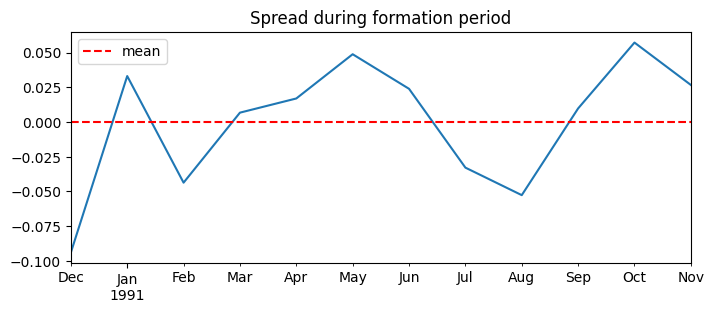

In [7]:
y_formation = formation_data[stock_A]
x_formation = formation_data[stock_B]

spread_formation = y_formation - alpha - beta * x_formation

mu_S = spread_formation.mean()
sigma_S = spread_formation.std()

print(f"mu_S: {mu_S:.4f}")
print(f"sigma_S: {sigma_S:.4f}")

spread_formation.plot(figsize=(8,3), title="Spread during formation period")
plt.axhline(mu_S, color='red', linestyle='--', label='mean')
plt.legend()
plt.show()

1991-12-31    4.275136
1992-01-31    3.003767
1992-02-28    3.476710
1992-03-31    3.692191
1992-04-30    2.467245
1992-05-29    2.932841
dtype: float64


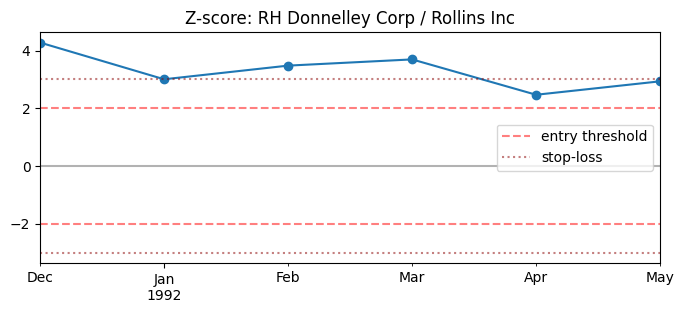

In [8]:
#stessa cosa ma nel trading period 
y_trading = trading_data[stock_A]
x_trading = trading_data[stock_B]

spread_trading = y_trading - alpha - beta * x_trading

z_score = (spread_trading - mu_S) / sigma_S

print(z_score)

z_score.plot(figsize=(8,3), title=f"Z-score: {ticker_to_name.get(stock_A)} / {ticker_to_name.get(stock_B)}", marker='o')
plt.axhline(2, color='red', linestyle='--', alpha=0.5, label='entry threshold')
plt.axhline(-2, color='red', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.axhline(3, color='darkred', linestyle=':', alpha=0.5, label='stop-loss')
plt.axhline(-3, color='darkred', linestyle=':', alpha=0.5)
plt.legend()
plt.show()

In [9]:
position = 0
positions_over_time = []

for t in z_score.index:
    z = z_score.loc[t]
    
    if position == 0:
        if 2 <= z < 3:
            position = -1
        elif -3 < z <= -2:
            position = 1
    
    elif position == -1:
        if z <= 0 or z >= 3:
            position = 0
    
    elif position == 1:
        if z >= 0 or z <= -3:
            position = 0
    
    positions_over_time.append(position)

positions_series = pd.Series(positions_over_time, index=z_score.index)
print(positions_series)

1991-12-31    0
1992-01-31    0
1992-02-28    0
1992-03-31    0
1992-04-30   -1
1992-05-29   -1
dtype: int64


### Forced closure at end of trading period

If a position remains open at the end of the 6-month trading window (neither converged 
nor stopped out), it is closed regardless, at the last available price. This is 
necessary because the next cycle uses an entirely different formation window and 
re-estimated parameters ($\hat\alpha$, $\hat\beta$, $\mu_S$, $\sigma_S$); carrying a 
position forward across cycles would not be consistent with the rolling structure of 
the strategy.

In [10]:
trading_returns_A = log_returns_final.loc[trading_data.index, stock_A]
trading_returns_B = log_returns_final.loc[trading_data.index, stock_B]

effective_position = positions_series.shift(1)

pair_return = effective_position * (trading_returns_A - beta * trading_returns_B)
pair_return = pair_return.dropna()

print(pair_return)

1992-01-31   -0.000000
1992-02-28    0.000000
1992-03-31    0.000000
1992-04-30   -0.000000
1992-05-29   -0.021309
dtype: float64


### Single-pair worked example — result

For the RH Donnelley / Rollins pair in cycle 0, the position remains flat for the first 
four months of trading (z-score never enters the valid entry band of [2,3)), opens a 
short-spread position in April 1992 (z = 2.47), and remains open through the end of the 
trading period without converging or triggering the stop-loss — it is closed at the 
final available price as per the forced-closure rule. The realized return is zero for 
the months without an open position, and -2.13% in May 1992, consistent with the spread 
widening further (z rising from 2.47 to 2.93) rather than reverting, which is a loss 
for a short-spread position betting on convergence.

In [11]:
def backtest_pair(cycle, pair_row, log_prices_final, log_returns_final, 
                   entry_low=2, entry_high=3, exit_z=0, stop_z=3):
    
    stock_A = pair_row["stock_A"]
    stock_B = pair_row["stock_B"]
    alpha = pair_row["alpha"]
    beta = pair_row["beta"]
    
    formation_data = log_prices_final.loc[cycle["formation_start"]:cycle["formation_end"]]
    trading_data = log_prices_final.loc[cycle["trading_start"]:cycle["trading_end"]]
    
    spread_formation = formation_data[stock_A] - alpha - beta * formation_data[stock_B]
    mu_S = spread_formation.mean()
    sigma_S = spread_formation.std()
    
    if sigma_S == 0 or pd.isna(sigma_S):
        return pd.Series(dtype=float)
    
    spread_trading = trading_data[stock_A] - alpha - beta * trading_data[stock_B]
    z_score = (spread_trading - mu_S) / sigma_S
    
    position = 0
    positions_over_time = []
    
    for t in z_score.index:
        z = z_score.loc[t]
        
        if position == 0:
            if entry_low <= z < entry_high:
                position = -1
            elif -entry_high < z <= -entry_low:
                position = 1
        
        elif position == -1:
            if z <= exit_z or z >= stop_z:
                position = 0
        
        elif position == 1:
            if z >= exit_z or z <= -stop_z:
                position = 0
        
        positions_over_time.append(position)
    
    positions_series = pd.Series(positions_over_time, index=z_score.index)
    
    returns_A = log_returns_final.loc[trading_data.index, stock_A]
    returns_B = log_returns_final.loc[trading_data.index, stock_B]
    
    effective_position = positions_series.shift(1)
    pair_return = effective_position * (returns_A - beta * returns_B)
    pair_return = pair_return.dropna()
    
    return pair_return

In [13]:
all_pair_returns = {}

for cycle_id, cycle in cycles_df.iterrows():
    pairs_for_cycle = cycle_selections[cycle_id]
    
    for pair_idx, pair_row in pairs_for_cycle.iterrows():
        pair_return = backtest_pair(cycle, pair_row, log_prices_final, log_returns_final)
        
        key = (cycle_id, pair_row["stock_A"], pair_row["stock_B"])
        all_pair_returns[key] = pair_return

print(f"Total pair-cycle backtests computed: {len(all_pair_returns)}")

Total pair-cycle backtests computed: 1080


In [14]:
n_with_activity = sum(1 for r in all_pair_returns.values() if (r != 0).any())
n_empty = sum(1 for r in all_pair_returns.values() if len(r) == 0)
n_total = len(all_pair_returns)

print(f"Pairs with at least one non-zero return: {n_with_activity} out of {n_total}")
print(f"Pairs with empty return series (sigma_S issue): {n_empty}")

Pairs with at least one non-zero return: 577 out of 1080
Pairs with empty return series (sigma_S issue): 8


### Trading activity summary

577 of the 1,080 pair-cycle combinations (53.4%) generated at least one trade during 
their trading period; the rest never had a z-score fall within the valid entry band 
during the 6-month window, which is an expected outcome of the strategy's signal-driven 
nature, not an error. A negligible 8 pairs (0.7%) have an empty return series due to a 
near-zero formation-period spread variance.

### Aggregating to cycle-level portfolio returns

Each cycle holds 20 pairs simultaneously, so we combine their individual return series 
into a single portfolio return per month using an **equal-weight** scheme: at each date, 
the cycle's portfolio return is the simple average of the 20 pairs' returns at that 
date. Pairs with no open position in a given month contribute exactly 0 to that month's 
average, consistent with capital sitting idle rather than being reallocated — this 
keeps the equal-weight assumption intact (each pair always represents 1/20 of capital) 
rather than redistributing weight away from inactive pairs.

In [15]:
cycle_portfolio_returns = {}

for cycle_id, cycle in cycles_df.iterrows():
    trading_dates = log_prices_final.loc[cycle["trading_start"]:cycle["trading_end"]].index[1:]
    
    pairs_for_cycle = cycle_selections[cycle_id]
    
    returns_matrix = pd.DataFrame(index=trading_dates)
    
    for pair_idx, pair_row in pairs_for_cycle.iterrows():
        key = (cycle_id, pair_row["stock_A"], pair_row["stock_B"])
        pair_return = all_pair_returns[key]
        
        returns_matrix[pair_idx] = pair_return.reindex(trading_dates, fill_value=0)
    
    cycle_portfolio_returns[cycle_id] = returns_matrix.mean(axis=1)

print(cycle_portfolio_returns[0])

1992-01-31    0.002983
1992-02-28    0.011372
1992-03-31    0.004193
1992-04-30    0.002401
1992-05-29   -0.009548
dtype: float64


### Note: log-return averaging approximation

The cycle-level portfolio return is computed as a simple average of 20 individual 
pair log-returns. Strictly speaking, the log-return of an equal-weighted portfolio is 
not exactly the average of the constituents' log-returns (the log of an average is not 
the average of logs) — this is a standard small-returns approximation, accurate to a 
first order and routinely used in practice for monthly equity data, but technically an 
approximation rather than an identity. We adopt it here for simplicity, consistent with 
working in log-return space throughout the project.

In [16]:
full_dates = []
for _, cycle in cycles_df.iterrows():
    cycle_dates = log_prices_final.loc[cycle["trading_start"]:cycle["trading_end"]].index
    full_dates.extend(cycle_dates.tolist())

full_dates = pd.Index(sorted(set(full_dates)))

all_returns = pd.concat([cycle_portfolio_returns[i] for i in range(len(cycles_df))])
all_returns = all_returns.sort_index()

strategy_returns = all_returns.reindex(full_dates, fill_value=0)

print(strategy_returns.shape)
strategy_returns.head(10)

(324,)


1991-12-31    0.000000
1992-01-31    0.002983
1992-02-28    0.011372
1992-03-31    0.004193
1992-04-30    0.002401
1992-05-29   -0.009548
1992-06-30    0.000000
1992-07-31    0.015197
1992-08-31   -0.004907
1992-09-30   -0.007672
dtype: float64

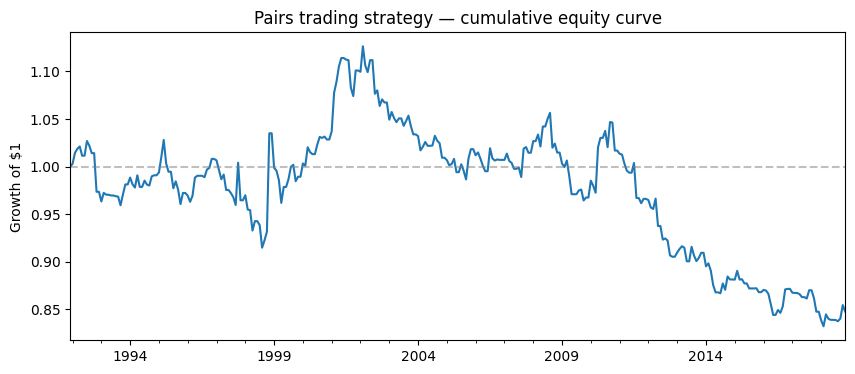

In [17]:
cumulative_log_return = strategy_returns.cumsum()
equity_curve = np.exp(cumulative_log_return)

equity_curve.plot(figsize=(10,4), title="Pairs trading strategy — cumulative equity curve")
plt.ylabel("Growth of $1")
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.show()

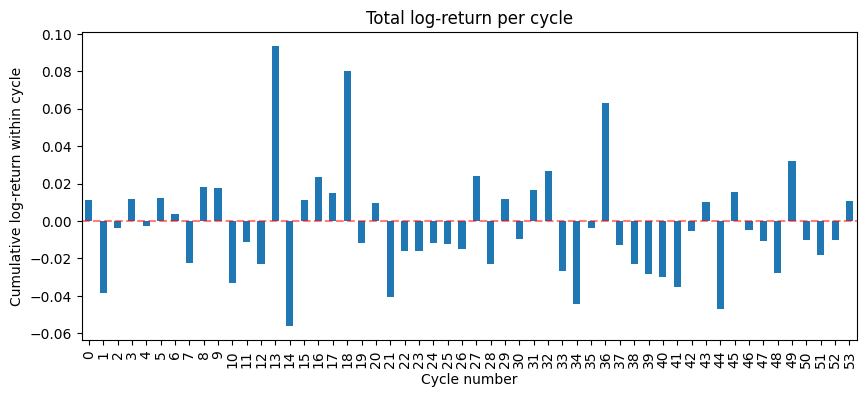

In [18]:
cycle_total_returns = {}

for cycle_id in range(len(cycles_df)):
    cycle_total_returns[cycle_id] = cycle_portfolio_returns[cycle_id].sum()

cycle_returns_series = pd.Series(cycle_total_returns)

cycle_returns_series.plot(figsize=(10,4), kind='bar', title="Total log-return per cycle")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel("Cycle number")
plt.ylabel("Cumulative log-return within cycle")
plt.show()

In [19]:
correlation = cycle_returns_series.reset_index()[0].corr(pd.Series(cycle_returns_series.index))
print(f"Correlation between cycle number and cycle return: {correlation:.3f}")

first_half_mean = cycle_returns_series.iloc[:27].mean()
second_half_mean = cycle_returns_series.iloc[27:].mean()

print(f"Mean return - first 27 cycles: {first_half_mean:.4f}")
print(f"Mean return - last 27 cycles: {second_half_mean:.4f}")

Correlation between cycle number and cycle return: -0.124
Mean return - first 27 cycles: -0.0002
Mean return - last 27 cycles: -0.0059


### **Diagnostic: is performance decay systematic over time?**

We tested whether the apparent decline in the equity curve after ~2002 reflects a 
systematic time trend (e.g. consistent with an increasingly larger, noisier stock 
universe inflating the multiple testing problem over time) or simply higher variance 
without clear direction.

The correlation between cycle number and cycle return is weak (-0.124): directionally 
consistent with later cycles performing slightly worse, but far from a strong systematic 
trend. Comparing average returns between the first and second half of the sample (27 
cycles each), the first half averages essentially zero (-0.0002), not positive — the 
equity curve's early rise is driven by a small number of outlier cycles (notably cycles 
13 and 18, falling within the late-1990s dot-com period) rather than a sustained period 
of outperformance. The second half averages more negative (-0.0059), a modest but not 
dramatic deterioration.

We therefore do not find strong evidence that a growing candidate universe is the 
primary driver of the strategy's overall underperformance; the result is more 
consistent with a strategy whose average cycle return is close to zero (or mildly 
negative) throughout, punctuated by a few large outlier cycles, rather than a clear 
structural decay over time. This is consistent with — though does not exclusively 
confirm — the data dredging concern raised earlier in Block 2.

In [20]:
strategy_returns.to_csv("strategy_returns.csv", header=["return"])

cycle_returns_series.to_csv("cycle_returns_series.csv", header=["total_return"])

import pickle

with open("all_pair_returns.pkl", "wb") as f:
    pickle.dump(all_pair_returns, f)

with open("cycle_portfolio_returns.pkl", "wb") as f:
    pickle.dump(cycle_portfolio_returns, f)

print("Saved: strategy_returns.csv, cycle_returns_series.csv, all_pair_returns.pkl, cycle_portfolio_returns.pkl")

Saved: strategy_returns.csv, cycle_returns_series.csv, all_pair_returns.pkl, cycle_portfolio_returns.pkl


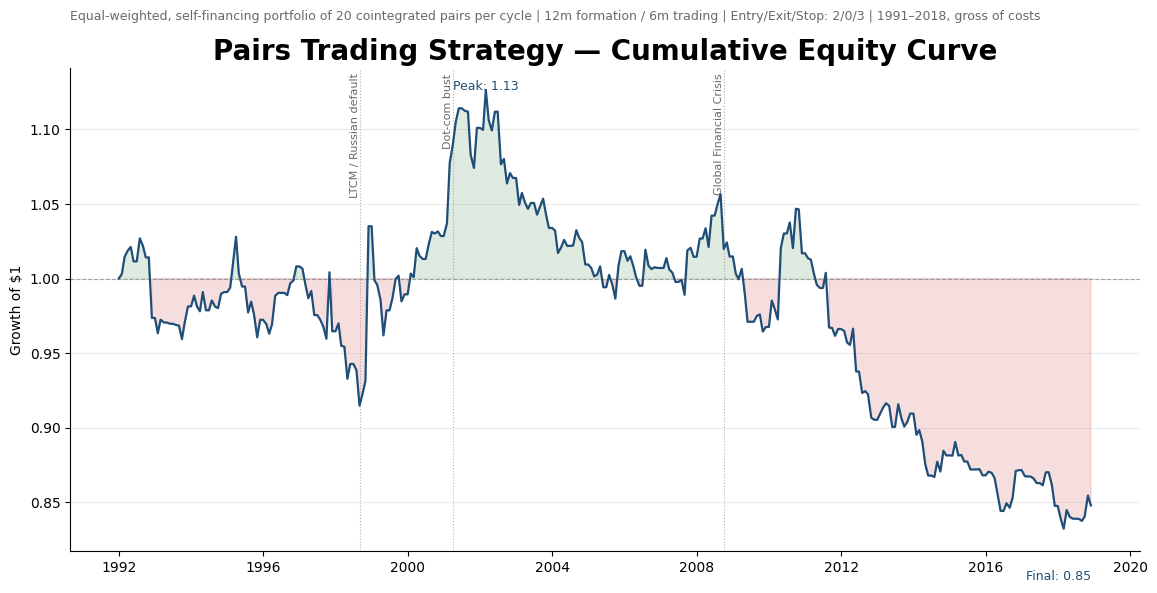

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(equity_curve.index, equity_curve.values, color="#1f4e79", linewidth=1.6, zorder=3)

ax.fill_between(equity_curve.index, equity_curve.values, 1.0,
                 where=(equity_curve.values >= 1.0), color="#2e7d32", alpha=0.15, zorder=1)
ax.fill_between(equity_curve.index, equity_curve.values, 1.0,
                 where=(equity_curve.values < 1.0), color="#c62828", alpha=0.15, zorder=1)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

events = {
    "1998-08-31": "LTCM / Russian default",
    "2001-03-31": "Dot-com bust",
    "2008-09-30": "Global Financial Crisis",
}
for date_str, label in events.items():
    date = pd.Timestamp(date_str)
    if equity_curve.index.min() <= date <= equity_curve.index.max():
        ax.axvline(date, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
        ax.text(date, ax.get_ylim()[1]*0.997, label, rotation=90, fontsize=8,
                 va="top", ha="right", color="dimgray")

peak_date = equity_curve.idxmax()
peak_val = equity_curve.max()
final_val = equity_curve.iloc[-1]

ax.annotate(f"Peak: {peak_val:.2f}", xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val ), fontsize=9, ha="center", color="#1f4e79")
ax.annotate(f"Final: {final_val:.2f}", xy=(equity_curve.index[-1], final_val),
            xytext=(equity_curve.index[-1], final_val - 0.05), fontsize=9, ha="right", color="#1f4e79")

ax.set_title("Pairs Trading Strategy — Cumulative Equity Curve", fontsize=20, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Growth of $1")
ax.text(0, 1.10,
        "Equal-weighted, self-financing portfolio of 20 cointegrated pairs per cycle | "
        "12m formation / 6m trading | Entry/Exit/Stop: 2/0/3 | 1991\u20132018, gross of costs",
        transform=ax.transAxes, fontsize=9, color="dimgray")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Block 3 recap — Backtest: trading signal and equity curve

For each of the 20 pairs selected per cycle (Block 2), we constructed the out-of-sample 
trading signal: the spread $S_t = y_t - \hat\alpha - \hat\beta x_t$ during the trading 
period, standardized into a z-score using the mean and standard deviation of the spread 
**estimated in the formation period** ($\mu_S = 0$ by construction, an algebraic property 
of OLS residuals). This rescaling allows the same entry/exit/stop-loss thresholds to be 
applied uniformly across all pairs and cycles.

We implemented a position state machine with the following rules: a position opens only 
if the entry signal falls within $2 \leq |z_t| < 3$ — deliberately excluding cases where 
the signal is already beyond the stop-loss level at the moment of entry, a design choice 
motivated by risk management rather than dictated by the reference paper (which has no 
stop-loss at all). An open position closes on convergence ($z$ crossing 0) or stop-loss 
($|z| \geq 3$), and any position still open at the end of the trading period is closed 
by force, since parameters are re-estimated independently each cycle.

We fixed an explicit timing convention to avoid look-ahead bias: a position decided using 
$z_t$ (observed at month $t$) earns its return over the following month ($t \to t+1$), 
since the price move within month $t$ itself has already occurred by the time $z_t$ is 
observed. A consequence of this convention is that the first month of each 6-month 
trading window never generates a realized return — no decision exists yet for it — 
which we make explicit by filling these months with zero return rather than silently 
skipping them.

Pair-level returns were aggregated into a cycle-level portfolio return via simple 
equal-weight averaging across the 20 pairs (inactive pairs contributing zero, not 
excluded from the average), then concatenated across all 54 non-overlapping cycles into 
a single continuous monthly return series spanning the full 1991–2018 sample (324 
months).

**Result.** The resulting equity curve shows modest growth until approximately 2002 
(driven by a small number of outlier cycles, notably around the dot-com period) followed 
by a near-continuous decline, ending around -15% over the full sample. A diagnostic 
check found only a weak correlation (-0.124) between cycle number and cycle return, and 
a modest difference between first-half and second-half average cycle returns 
(-0.0002 vs -0.0059) — suggesting the underperformance is not primarily driven by a 
growing, noisier candidate universe over time, but is more consistent with a strategy 
whose average cycle return hovers near zero throughout, consistent with the data 
dredging concern raised in Block 2.

**Known limitations, acknowledged explicitly:**
- Cycle-level returns are computed as a simple average of pair log-returns, a standard 
  but technically approximate treatment of portfolio log-returns (the log of an average 
  is not the average of logs).
- No transaction costs are included at this stage; given the strategy already shows a 
  net loss gross of costs, including them would only worsen the result.
- The weak economic coherence of selected pairs (Block 2 limitation) likely contributes 
  to the modest, near-zero average performance observed here.

**Outputs saved:** `strategy_returns.csv` (the full 324-month return series), 
`cycle_returns_series.csv` (total return per cycle), and `all_pair_returns.pkl` / 
`cycle_portfolio_returns.pkl` (full pair- and cycle-level detail), all ready to be used 
in Block 4 for risk/performance metrics and benchmark comparison.

In [27]:
def run_full_backtest(entry_low, entry_high, exit_z, stop_z):
    all_pair_returns_v2 = {}
    for cycle_id, cycle in cycles_df.iterrows():
        pairs_for_cycle = cycle_selections[cycle_id]
        for pair_idx, pair_row in pairs_for_cycle.iterrows():
            pair_return = backtest_pair(cycle, pair_row, log_prices_final, log_returns_final,
                                         entry_low=entry_low, entry_high=entry_high,
                                         exit_z=exit_z, stop_z=stop_z)
            key = (cycle_id, pair_row["stock_A"], pair_row["stock_B"])
            all_pair_returns_v2[key] = pair_return
    
    cycle_portfolio_returns_v2 = {}
    for cycle_id, cycle in cycles_df.iterrows():
        trading_dates = log_prices_final.loc[cycle["trading_start"]:cycle["trading_end"]].index[1:]
        pairs_for_cycle = cycle_selections[cycle_id]
        returns_matrix = pd.DataFrame(index=trading_dates)
        for pair_idx, pair_row in pairs_for_cycle.iterrows():
            key = (cycle_id, pair_row["stock_A"], pair_row["stock_B"])
            pr = all_pair_returns_v2[key]
            returns_matrix[pair_idx] = pr.reindex(trading_dates, fill_value=0)
        cycle_portfolio_returns_v2[cycle_id] = returns_matrix.mean(axis=1)
    
    all_returns_v2 = pd.concat([cycle_portfolio_returns_v2[i] for i in range(len(cycles_df))]).sort_index()
    strategy_returns_v2 = all_returns_v2.reindex(full_dates, fill_value=0)
    
    return strategy_returns_v2

strategy_returns_v2 = run_full_backtest(entry_low=2, entry_high=2.5, exit_z=0.5, stop_z=2.5)
equity_curve_v2 = np.exp(strategy_returns_v2.cumsum())

print(equity_curve_v2.tail())

2018-07-31    1.003782
2018-08-31    1.003055
2018-09-28    1.000501
2018-10-31    1.016390
2018-11-30    1.016390
dtype: float64


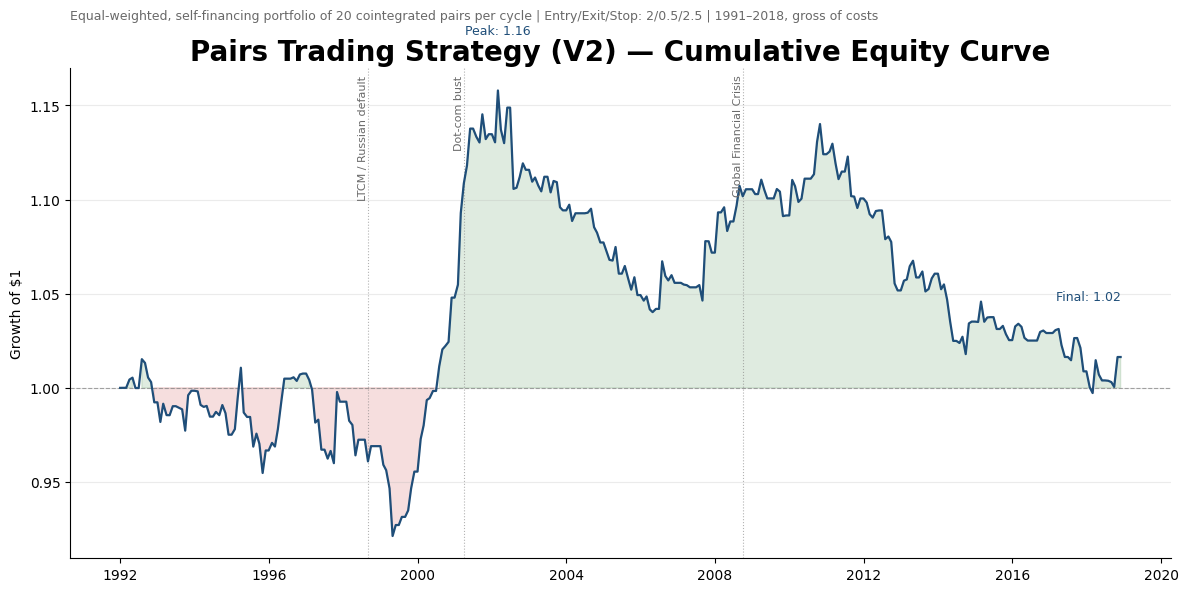

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(equity_curve_v2.index, equity_curve_v2.values, color="#1f4e79", linewidth=1.6, zorder=3)

ax.fill_between(equity_curve_v2.index, equity_curve_v2.values, 1.0,
                 where=(equity_curve_v2.values >= 1.0), color="#2e7d32", alpha=0.15, zorder=1)
ax.fill_between(equity_curve_v2.index, equity_curve_v2.values, 1.0,
                 where=(equity_curve_v2.values < 1.0), color="#c62828", alpha=0.15, zorder=1)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

events = {
    "1998-08-31": "LTCM / Russian default",
    "2001-03-31": "Dot-com bust",
    "2008-09-30": "Global Financial Crisis",
}
for date_str, label in events.items():
    date = pd.Timestamp(date_str)
    if equity_curve_v2.index.min() <= date <= equity_curve_v2.index.max():
        ax.axvline(date, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
        ax.text(date, ax.get_ylim()[1]*0.997, label, rotation=90, fontsize=8,
                 va="top", ha="right", color="dimgray")

peak_date = equity_curve_v2.idxmax()
peak_val = equity_curve_v2.max()
final_val = equity_curve_v2.iloc[-1]

ax.annotate(f"Peak: {peak_val:.2f}", xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val + 0.03), fontsize=9, ha="center", color="#1f4e79")
ax.annotate(f"Final: {final_val:.2f}", xy=(equity_curve_v2.index[-1], final_val),
            xytext=(equity_curve_v2.index[-1], final_val + 0.03), fontsize=9, ha="right", color="#1f4e79")

ax.set_title("Pairs Trading Strategy (V2) — Cumulative Equity Curve", fontsize=20, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Growth of $1")
ax.text(0, 1.10,
        "Equal-weighted, self-financing portfolio of 20 cointegrated pairs per cycle | "
        "Entry/Exit/Stop: 2/0.5/2.5 | 1991\u20132018, gross of costs",
        transform=ax.transAxes, fontsize=9, color="dimgray")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

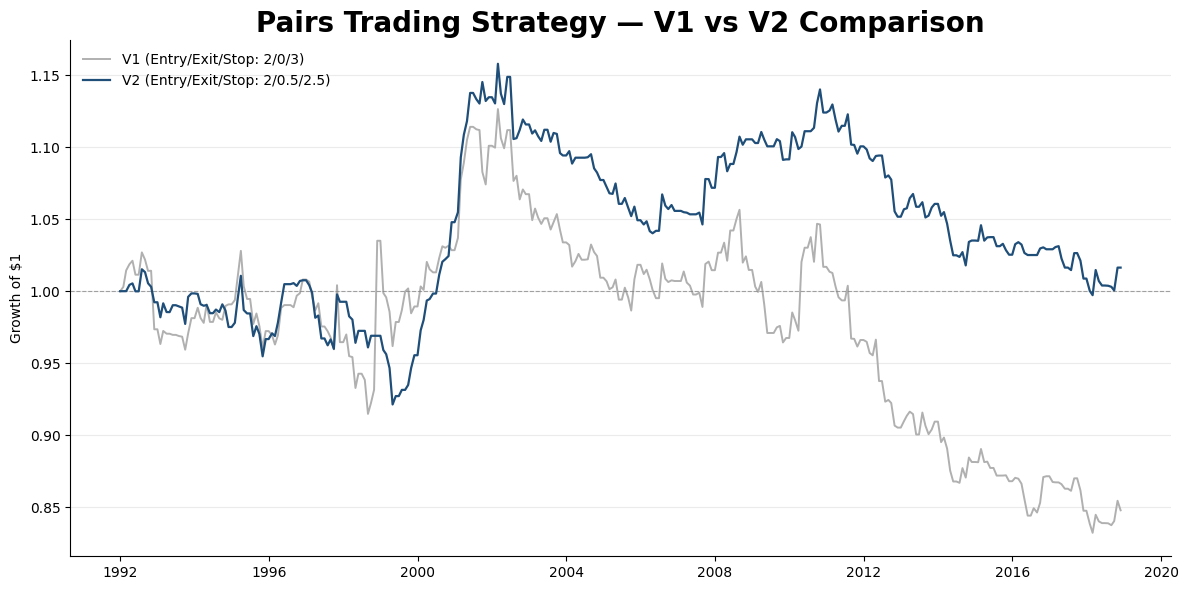

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(equity_curve.index, equity_curve.values, color="#b0b0b0", linewidth=1.4, 
        label="V1 (Entry/Exit/Stop: 2/0/3)", zorder=2)
ax.plot(equity_curve_v2.index, equity_curve_v2.values, color="#1f4e79", linewidth=1.6, 
        label="V2 (Entry/Exit/Stop: 2/0.5/2.5)", zorder=3)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

ax.set_title("Pairs Trading Strategy — V1 vs V2 Comparison", fontsize=20, fontweight="bold")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### V1 vs V2 — a methodological caveat

Switching from V1 (entry/exit/stop = 2/0/3) to V2 (2/0.5/2.5) — earlier profit-taking 
and a tighter stop-loss — improves the final outcome substantially: from -15.7% (V1) to 
+1.6% (V2) cumulative over 1991–2018, with a higher peak (1.16 vs 1.13).

This comparison should be read with an important caveat: V2's parameters were chosen 
*after* observing V1's full-sample result, not validated on a separate sample. This is 
a single ad-hoc adjustment, not a rigorous walk-forward optimization, and the improvement 
could partly reflect fitting to this specific historical sample rather than a genuinely 
better rule. A more rigorous approach — choosing thresholds on the first half of the 
sample and testing them, unseen, on the second half — would be needed to validate this 
improvement out-of-sample; we note this as a possible extension if time allows, rather 
than claiming this result as conclusively superior.

In [36]:
strategy_returns_v2.to_csv("strategy_returns_v2.csv", header=["return"])

equity_curve_v2.to_csv("equity_curve_v2.csv", header=["equity"])

print("Saved: strategy_returns_v2.csv, equity_curve_v2.csv")

Saved: strategy_returns_v2.csv, equity_curve_v2.csv


## Block 3 recap — Backtest: trading signal, equity curve, and parameter exploration

For each of the 20 pairs selected per cycle (Block 2), we constructed the out-of-sample 
trading signal: the spread $S_t = y_t - \hat\alpha - \hat\beta x_t$ during the trading 
period, standardized into a z-score using the formation-period mean and standard 
deviation ($\mu_S = 0$ by construction). We implemented a position state machine with 
entry only in the band $2 \leq |z_t| < 3$ (explicitly avoiding entries already beyond 
the stop-loss level), exit on convergence or stop-loss, and forced closure at the end of 
each trading period. A strict timing convention (decision at $t$, return realized over 
$t \to t+1$) was enforced throughout to avoid look-ahead bias.

Pair-level returns were aggregated (equal-weight) into cycle-level portfolio returns, 
then concatenated across all 54 cycles into a continuous monthly series spanning 
1991–2018 (324 months).

**V1 (entry/exit/stop = 2/0/3):** the resulting equity curve grows modestly until 
~2002 (driven by a few outlier cycles), then declines through the rest of the sample, 
ending at a cumulative **-15.7%** (final value 0.84).

**V2 (entry/exit/stop = 2/0.5/2.5):** as an exploratory robustness check, we tested 
earlier profit-taking (exit before full convergence) and a tighter stop-loss. This 
substantially improved the outcome — final value 1.02, i.e. **+1.6% cumulative** 
(0.073% annualized) — with a higher peak (1.16 vs 1.13) and a shallower drawdown 
throughout. We explicitly flag a methodological caveat: V2's parameters were chosen 
*after* observing V1's full-sample result, not validated on a separate out-of-sample 
period, so this comparison should be read as an exploratory adjustment rather than a 
rigorously validated improvement. A proper validation would require choosing thresholds 
on part of the sample and testing them, unseen, on the rest.

**Context from the literature.** Even the improved V2 result (0.073% annualized) is 
economically negligible — below virtually any risk-free benchmark over this period, and 
before transaction costs. This is consistent with, not contradicted by, the academic 
literature: Do and Faff document a continuous decline in pairs trading profitability, 
from 0.86%/month (1962-1988) to 0.24%/month (2003-2009), and find the classic Gatev et 
al. algorithm largely unprofitable after 2002 — the same point where our equity curve 
turns down. They also find profitability concentrates in industry-homogeneous pairs, a 
restriction we could not apply due to unreliable sector data (Block 2). The weak result 
is therefore plausibly explained by documented structural decay in this strategy class, 
combined with our specific implementation constraints, rather than indicating an error 
in the analysis.

**Outputs carried forward to Block 4:** `strategy_returns` (V1) and `strategy_returns_v2` 
(V2), both spanning the full 324-month sample, ready to be compared against an 
equal-weight buy-and-hold benchmark of the same stock universe.

In [37]:
strategy_returns = pd.read_csv("strategy_returns.csv", index_col=0, parse_dates=True)["return"]
cycle_returns_series = pd.read_csv("cycle_returns_series.csv", index_col=0)["total_return"]

with open("all_pair_returns.pkl", "rb") as f:
    all_pair_returns = pickle.load(f)

with open("cycle_portfolio_returns.pkl", "rb") as f:
    cycle_portfolio_returns = pickle.load(f)

strategy_returns_v2 = pd.read_csv("strategy_returns_v2.csv", index_col=0, parse_dates=True)["return"]
equity_curve_v2 = pd.read_csv("equity_curve_v2.csv", index_col=0, parse_dates=True)["equity"]

print("Reloaded successfully")

Reloaded successfully


---------
## **BLOCK 4 — Benchmark comparison**

To judge whether the pairs trading strategy adds value, we compare it against a passive 
**equal-weight buy-and-hold benchmark** built from the same 1,004-stock universe used 
throughout the project — not an external index, but a portfolio that simply holds all 
available stocks with no active selection or trading, over the identical 1991–2018 
period used for the strategy backtest. This isolates the effect of the pairs trading 
logic itself, rather than comparing against a differently-constructed market index.

In [38]:
benchmark_returns = log_returns_final.loc[full_dates].mean(axis=1, skipna=True)

benchmark_equity_curve = np.exp(benchmark_returns.cumsum())

print(benchmark_equity_curve.tail())

2018-07-31    8.315938
2018-08-31    8.424399
2018-09-28    8.410943
2018-10-31    7.695111
2018-11-30    7.796515
dtype: float64


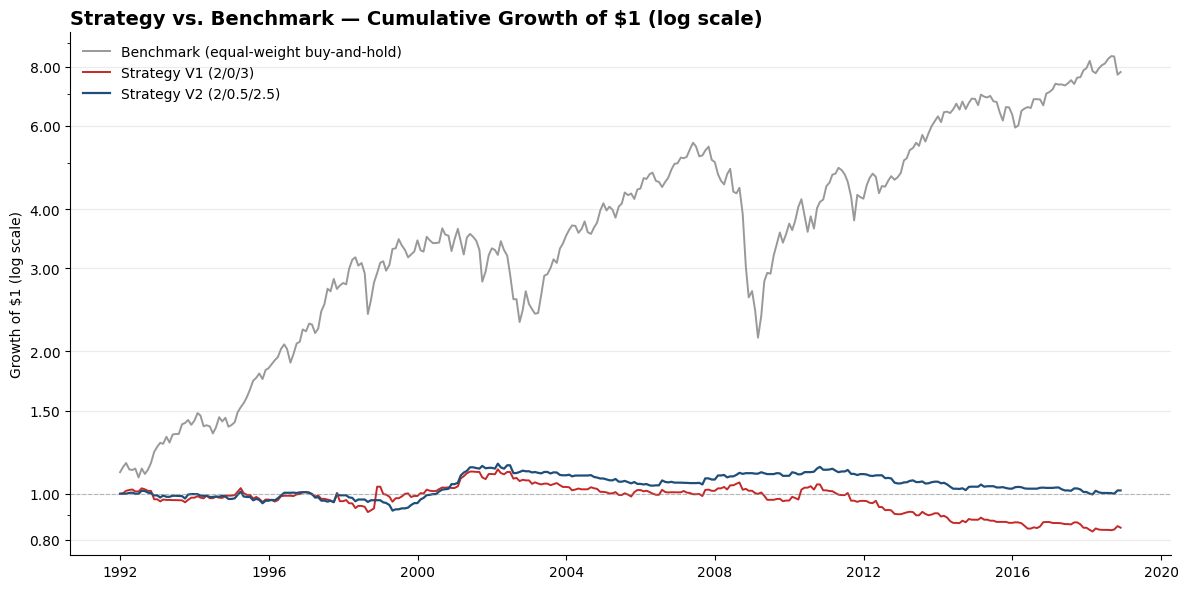

In [40]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(benchmark_equity_curve.index, benchmark_equity_curve.values, 
        color="#999999", linewidth=1.4, label="Benchmark (equal-weight buy-and-hold)")
ax.plot(equity_curve.index, equity_curve.values, 
        color="#c62828", linewidth=1.4, label="Strategy V1 (2/0/3)")
ax.plot(equity_curve_v2.index, equity_curve_v2.values, 
        color="#1f4e79", linewidth=1.6, label="Strategy V2 (2/0.5/2.5)")

ax.set_yscale("log")

yticks = [0.8, 1, 1.5, 2, 3, 4, 6, 8]
ax.set_yticks(yticks)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_title("Strategy vs. Benchmark — Cumulative Growth of $1 (log scale)", 
             fontsize=14, fontweight="bold", loc="left")
ax.set_ylabel("Growth of $1 (log scale)")
ax.legend(loc="upper left", frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="y", alpha=0.25, which="major")

plt.tight_layout()
plt.show()

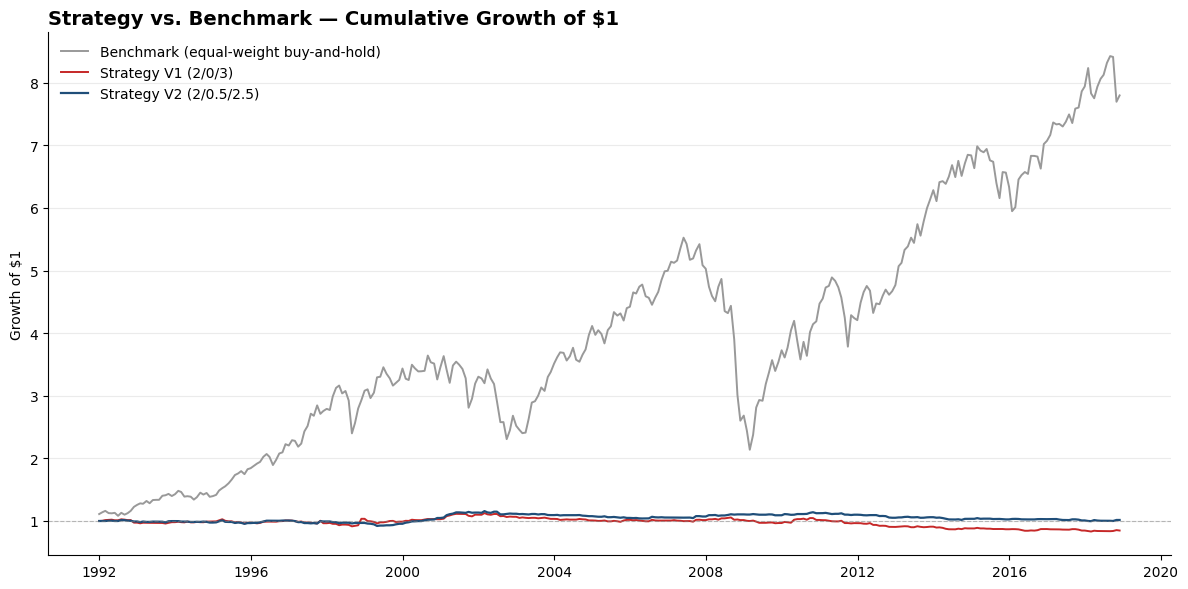

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(benchmark_equity_curve.index, benchmark_equity_curve.values, 
        color="#999999", linewidth=1.4, label="Benchmark (equal-weight buy-and-hold)")
ax.plot(equity_curve.index, equity_curve.values, 
        color="#c62828", linewidth=1.4, label="Strategy V1 (2/0/3)")
ax.plot(equity_curve_v2.index, equity_curve_v2.values, 
        color="#1f4e79", linewidth=1.6, label="Strategy V2 (2/0.5/2.5)")

ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_title("Strategy vs. Benchmark — Cumulative Growth of $1", 
             fontsize=14, fontweight="bold", loc="left")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [42]:
def compute_metrics(returns, risk_free=0.0):
    mean_monthly = returns.mean()
    std_monthly = returns.std()
    
    annualized_return = np.exp(mean_monthly * 12) - 1
    annualized_vol = std_monthly * np.sqrt(12)
    
    sharpe = (mean_monthly - risk_free/12) / std_monthly * np.sqrt(12)
    
    equity = np.exp(returns.cumsum())
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()
    
    return {
        "annualized_return": annualized_return,
        "annualized_vol": annualized_vol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_dd
    }

metrics_benchmark = compute_metrics(benchmark_returns)
metrics_v1 = compute_metrics(strategy_returns)
metrics_v2 = compute_metrics(strategy_returns_v2)

metrics_df = pd.DataFrame({
    "Benchmark": metrics_benchmark,
    "Strategy V1": metrics_v1,
    "Strategy V2": metrics_v2
}).T

print(metrics_df)

             annualized_return  annualized_vol  sharpe_ratio  max_drawdown
Benchmark             0.079030        0.168040      0.452643     -0.612998
Strategy V1          -0.006096        0.044165     -0.138447     -0.261266
Strategy V2           0.000602        0.029161      0.020648     -0.138795


### Risk-adjusted comparison — interpretation

The strategy's annualized volatility (4.4% for V1, 2.9% for V2) is substantially lower 
than the benchmark's (16.8%) — confirming that the hedge-ratio-based construction 
successfully neutralizes most market exposure, as a long-short pairs strategy is 
designed to do. This validates the mechanical correctness of the approach.

However, the risk-adjusted performance does not support the strategy as a source of 
value over this sample: the Sharpe ratio is negative for V1 (-0.138) and essentially 
flat for V2 (0.021), against 0.453 for the passive benchmark. Even after correctly 
adjusting for risk, a simple equal-weight buy-and-hold of the same universe outperforms 
both strategy variants. The lower maximum drawdown of the strategy (-26.1% / -13.9% vs 
-61.3%) is a direct consequence of its lower volatility, not evidence of a genuinely 
superior trading rule.

This result is consistent with the academic literature discussed earlier (Do and Faff): 
pairs trading Sharpe ratios have declined substantially since 2002, and our use of 
monthly (rather than daily) data, combined with the inability to restrict candidate 
pairs to economically coherent sectors, likely compounds this effect. The honest 
conclusion is that, within the scope and constraints of this project, the cointegration-
based pairs trading strategy does not produce attractive risk-adjusted returns relative 
to a passive alternative over 1991–2018 — a finding that is itself consistent with, and 
explainable through, documented structural changes in arbitrage profitability over time.

## Block 4 recap — Benchmark comparison and final assessment

We compared the pairs trading strategy against an equal-weight buy-and-hold benchmark 
built from the same 1,004-stock universe, over the identical 1991–2018 period, to 
isolate the effect of the trading logic itself from the choice of stock universe.

In absolute terms, the benchmark dominates: a $1 investment grows to $7.80 (+680%, 
~7.9% annualized), against -15.7% for Strategy V1 and +1.6% for Strategy V2. However, 
this comparison alone is misleading, since the pairs trading strategy is constructed to 
be market-neutral (long-short, hedge-ratio weighted) and is therefore not designed to 
capture broad market appreciation the way a fully invested benchmark does.

The risk-adjusted comparison gives a more complete picture:

| | Annualized Return | Annualized Vol. | Sharpe Ratio | Max Drawdown |
|---|---|---|---|---|
| Benchmark | 7.90% | 16.80% | 0.453 | -61.3% |
| Strategy V1 | -0.61% | 4.42% | -0.138 | -26.1% |
| Strategy V2 | 0.06% | 2.92% | 0.021 | -13.9% |

The strategy's volatility is 4–6x lower than the benchmark's, confirming that the 
hedge-ratio construction correctly neutralizes most market exposure — the mechanical 
core of the strategy works as intended. However, even after adjusting for this much 
lower risk, neither strategy variant achieves a Sharpe ratio competitive with the 
passive benchmark (0.453): V1 is negative, V2 is essentially flat.

**Overall conclusion.** Within the scope of this project, the cointegration-based pairs 
trading strategy, implemented on monthly S&P500 data over 1991–2018, does not generate 
attractive risk-adjusted returns relative to a simple passive alternative. This is not 
attributed to an implementation error: the signal construction, timing convention, and 
position logic were validated step by step and behave as designed. Rather, the result 
is consistent with documented findings in the academic literature (Do and Faff, 2010, 
2012), which show pairs trading profitability declining sharply after 2002 — the same 
point where our equity curve turns down — and concentrating in industry-homogeneous 
pairs, a restriction we could not apply due to unreliable sector data in the source 
file (Block 2). The combination of monthly (rather than daily) data, a sample period 
weighted toward the post-2002 decline, and the absence of a reliable sector filter are 
plausible, literature-grounded explanations for the weak result — a finding we report 
as a genuine, well-supported empirical conclusion rather than a project shortcoming.

**Limitations carried through the full analysis, summarized:**
- Forward-fill correction (Block 1) has a known blind spot for stocks that resume 
  trading after a long flat period (e.g. AMD).
- Sector classification in the source data was found unreliable and abandoned (Block 2), 
  removing an economically motivated filter and weakening pair coherence.
- The 12-month formation window, fixed by convention, limits statistical power per test 
  despite FDR correction, and the large number of candidate pairs makes some 
  spurious cointegration plausible (data dredging).
- No transaction costs are included; given the strategy is already near break-even or 
  negative gross of costs, including them would only weaken the result further.
- The risk-free rate is assumed to be 0% for Sharpe ratio calculations, a simplification 
  that slightly overstates all Sharpe ratios shown.